Based on https://github.com/davidADSP/Generative_Deep_Learning_2nd_Edition/blob/main/notebooks/11_music/01_transformer/transformer.ipynb

Sample outputs found at deep_learning/Generative_Deep_Learning_2nd_Edition/outputs/music_gen 

# Install Musescore

In [26]:
!apt-get update
!apt-get install -y musescore

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [105 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [356 B]       
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,899 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]           
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]       
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.7 MB]  
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1

In [30]:
# Check if mscore is installed
!which mscore

/usr/bin/mscore


In [ ]:
# needed to create a symbolic link for mscore3 to mscore, as some systems may have mscore3 installed instead of mscore
!ln -s /usr/bin/mscore /usr/bin/mscore3

# Create Directories

In [ ]:
import os
os.makedirs("./parsed_data", exist_ok=True)
os.makedirs("./logs", exist_ok=True)
os.makedirs("./models", exist_ok=True)
os.makedirs("./output", exist_ok=True)

In [3]:
import os
import pickle as pkl
import music21
import keras
import tensorflow as tf

from fractions import Fraction


def parse_midi_files(file_list, parser, seq_len, parsed_data_path=None):
    notes_list = []
    duration_list = []
    notes = []
    durations = []

    for i, file in enumerate(file_list):
        print(i + 1, "Parsing %s" % file)
        score = parser.parse(file).chordify()

        notes.append("START")
        durations.append("0.0")

        for element in score.flat:
            note_name = None
            duration_name = None

            if isinstance(element, music21.key.Key):
                note_name = str(element.tonic.name) + ":" + str(element.mode)
                duration_name = "0.0"

            elif isinstance(element, music21.meter.TimeSignature):
                note_name = str(element.ratioString) + "TS"
                duration_name = "0.0"

            elif isinstance(element, music21.chord.Chord):
                note_name = element.pitches[-1].nameWithOctave
                duration_name = str(element.duration.quarterLength)

            elif isinstance(element, music21.note.Rest):
                note_name = str(element.name)
                duration_name = str(element.duration.quarterLength)

            elif isinstance(element, music21.note.Note):
                note_name = str(element.nameWithOctave)
                duration_name = str(element.duration.quarterLength)

            if note_name and duration_name:
                notes.append(note_name)
                durations.append(duration_name)
        print(f"{len(notes)} notes parsed")

    notes_list = []
    duration_list = []

    print(f"Building sequences of length {seq_len}")
    for i in range(len(notes) - seq_len):
        notes_list.append(" ".join(notes[i : (i + seq_len)]))
        duration_list.append(" ".join(durations[i : (i + seq_len)]))

    if parsed_data_path:
        with open(os.path.join(parsed_data_path, "notes"), "wb") as f:
            pkl.dump(notes_list, f)
        with open(os.path.join(parsed_data_path, "durations"), "wb") as f:
            pkl.dump(duration_list, f)

    return notes_list, duration_list


def load_parsed_files(parsed_data_path):
    with open(os.path.join(parsed_data_path, "notes"), "rb") as f:
        notes = pkl.load(f)
    with open(os.path.join(parsed_data_path, "durations"), "rb") as f:
        durations = pkl.load(f)
    return notes, durations


def get_midi_note(sample_note, sample_duration):
    new_note = None

    if "TS" in sample_note:
        new_note = music21.meter.TimeSignature(sample_note.split("TS")[0])

    elif "major" in sample_note or "minor" in sample_note:
        tonic, mode = sample_note.split(":")
        new_note = music21.key.Key(tonic, mode)

    elif sample_note == "rest":
        new_note = music21.note.Rest()
        new_note.duration = music21.duration.Duration(
            float(Fraction(sample_duration))
        )
        new_note.storedInstrument = music21.instrument.Violoncello()

    elif "." in sample_note:
        notes_in_chord = sample_note.split(".")
        chord_notes = []
        for current_note in notes_in_chord:
            n = music21.note.Note(current_note)
            n.duration = music21.duration.Duration(
                float(Fraction(sample_duration))
            )
            n.storedInstrument = music21.instrument.Violoncello()
            chord_notes.append(n)
        new_note = music21.chord.Chord(chord_notes)

    elif sample_note == "rest":
        new_note = music21.note.Rest()
        new_note.duration = music21.duration.Duration(
            float(Fraction(sample_duration))
        )
        new_note.storedInstrument = music21.instrument.Violoncello()

    elif sample_note != "START":
        new_note = music21.note.Note(sample_note)
        new_note.duration = music21.duration.Duration(
            float(Fraction(sample_duration))
        )
        new_note.storedInstrument = music21.instrument.Violoncello()

    return new_note


class SinePositionEncoding(keras.layers.Layer):
    """Sinusoidal positional encoding layer.
    This layer calculates the position encoding as a mix of sine and cosine
    functions with geometrically increasing wavelengths. Defined and formulized
    in [Attention is All You Need](https://arxiv.org/abs/1706.03762).
    Takes as input an embedded token tensor. The input must have shape
    [batch_size, sequence_length, feature_size]. This layer will return a
    positional encoding the same size as the embedded token tensor, which
    can be added directly to the embedded token tensor.
    Args:
        max_wavelength: The maximum angular wavelength of the sine/cosine
            curves, as described in Attention is All You Need. Defaults to
            10000.
    Examples:
    ```python
    # create a simple embedding layer with sinusoidal positional encoding
    seq_len = 100
    vocab_size = 1000
    embedding_dim = 32
    inputs = keras.Input((seq_len,), dtype=tf.float32)
    embedding = keras.layers.Embedding(
        input_dim=vocab_size, output_dim=embedding_dim
    )(inputs)
    positional_encoding = keras_nlp.layers.SinePositionEncoding()(embedding)
    outputs = embedding + positional_encoding
    ```
    References:
     - [Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)
    """

    def __init__(
        self,
        max_wavelength=10000,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.max_wavelength = max_wavelength

    def call(self, inputs):
        # TODO(jbischof): replace `hidden_size` with`hidden_dim` for consistency
        # with other layers.
        input_shape = tf.shape(inputs)
        # length of sequence is the second last dimension of the inputs
        seq_length = input_shape[-2]
        hidden_size = input_shape[-1]
        position = tf.cast(tf.range(seq_length), self.compute_dtype)
        min_freq = tf.cast(1 / self.max_wavelength, dtype=self.compute_dtype)
        timescales = tf.pow(
            min_freq,
            tf.cast(2 * (tf.range(hidden_size) // 2), self.compute_dtype)
            / tf.cast(hidden_size, self.compute_dtype),
        )
        angles = tf.expand_dims(position, 1) * tf.expand_dims(timescales, 0)
        # even indices are sine, odd are cosine
        cos_mask = tf.cast(tf.range(hidden_size) % 2, self.compute_dtype)
        sin_mask = 1 - cos_mask
        # embedding shape is [seq_length, hidden_size]
        positional_encodings = (
            tf.sin(angles) * sin_mask + tf.cos(angles) * cos_mask
        )

        return tf.broadcast_to(positional_encodings, input_shape)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "max_wavelength": self.max_wavelength,
            }
        )
        return config

# Download Data

In [18]:
# Based on https://github.com/davidADSP/Generative_Deep_Learning_2nd_Edition/blob/main/scripts/downloaders/download_bach_cello_data.sh
# So it can run in Google Colab without docker and without bash script, and also to avoid downloading the files one by one.

import urllib.request
import os

# Create directory
os.makedirs("data/bach-cello", exist_ok=True)

urls = [
    "http://www.jsbach.net/midi/cs1-1pre.mid",
    "http://www.jsbach.net/midi/cs1-2all.mid",
    "http://www.jsbach.net/midi/cs1-3cou.mid",
    "http://www.jsbach.net/midi/cs1-4sar.mid",
    "http://www.jsbach.net/midi/cs1-5men.mid",
    "http://www.jsbach.net/midi/cs1-6gig.mid",
    "http://www.jsbach.net/midi/cs2-1pre.mid",
    "http://www.jsbach.net/midi/cs2-2all.mid",
    "http://www.jsbach.net/midi/cs2-3cou.mid",
    "http://www.jsbach.net/midi/cs2-4sar.mid",
    "http://www.jsbach.net/midi/cs2-5men.mid",
    "http://www.jsbach.net/midi/cs2-6gig.mid",
    "http://www.jsbach.net/midi/cs3-1pre.mid",
    "http://www.jsbach.net/midi/cs3-2all.mid",
    "http://www.jsbach.net/midi/cs3-3cou.mid",
    "http://www.jsbach.net/midi/cs3-4sar.mid",
    "http://www.jsbach.net/midi/cs3-5bou.mid",
    "http://www.jsbach.net/midi/cs3-6gig.mid",
    "http://www.jsbach.net/midi/cs4-1pre.mid",
    "http://www.jsbach.net/midi/cs4-2all.mid",
    "http://www.jsbach.net/midi/cs4-3cou.mid",
    "http://www.jsbach.net/midi/cs4-4sar.mid",
    "http://www.jsbach.net/midi/cs4-5bou.mid",
    "http://www.jsbach.net/midi/cs4-6gig.mid",
    "http://www.jsbach.net/midi/cs5-1pre.mid",
    "http://www.jsbach.net/midi/cs5-2all.mid",
    "http://www.jsbach.net/midi/cs5-3cou.mid",
    "http://www.jsbach.net/midi/cs5-4sar.mid",
    "http://www.jsbach.net/midi/cs5-5gav.mid",
    "http://www.jsbach.net/midi/cs5-6gig.mid",
    "http://www.jsbach.net/midi/cs6-1pre.mid",
    "http://www.jsbach.net/midi/cs6-2all.mid",
    "http://www.jsbach.net/midi/cs6-3cou.mid",
    "http://www.jsbach.net/midi/cs6-4sar.mid",
    "http://www.jsbach.net/midi/cs6-5gav.mid",
    "http://www.jsbach.net/midi/cs6-6gig.mid",
]

for url in urls:
    filename = url.split("/")[-1]
    filepath = os.path.join("data/bach-cello", filename)
    print(f"Downloading {filename}...", end=" ")
    urllib.request.urlretrieve(url, filepath)
    print("✓")

print("🚀 Done!")

🚀 Done!


# 🎶 Music Generation with Transformers

In this notebook, we'll walk through the steps required to train your own Transformer model to generate music in the style of the Bach cello suites

In [10]:
# %load_ext autoreload
# %autoreload 2

import os
import glob
import numpy as np
import time
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, losses, callbacks

import music21

# from transformer_utils import (
#     parse_midi_files,
#     load_parsed_files,
#     get_midi_note,
#     SinePositionEncoding,
# )

## 0. Parameters <a name="parameters"></a>

In [66]:
# PARSE_MIDI_FILES = True # first time only
PARSE_MIDI_FILES = False
# PARSED_DATA_PATH = "/app/notebooks/11_music/01_transformer/parsed_data/"
PARSED_DATA_PATH = "parsed_data/"
DATASET_REPETITIONS = 1

SEQ_LEN = 50
EMBEDDING_DIM = 256
KEY_DIM = 256
N_HEADS = 5
DROPOUT_RATE = 0.3
FEED_FORWARD_DIM = 256
LOAD_MODEL = False

# optimization
# EPOCHS = 5000
# EPOCHS = 2 # best for initial run, can be increased for better results
EPOCHS = 20 # best for initial run, can be increased for better results
BATCH_SIZE = 256

GENERATE_LEN = 50

OUTPUT_DIR = "output/"

## 1. Prepare the Data

In [19]:
import os
import subprocess

# Show current working directory
print("Current working directory:", os.getcwd())

# Check if the directory exists
print("\nContents of current directory:")
subprocess.run(["ls", "-la"])

# Search for .mid files
print("\nSearching for .mid files:")
subprocess.run(["find", ".", "-name", "*.mid", "-type", "f"])

Current working directory: /content

Contents of current directory:

Searching for .mid files:


CompletedProcess(args=['find', '.', '-name', '*.mid', '-type', 'f'], returncode=0)

In [20]:
# Load the data
# file_list = glob.glob("/app/data/bach-cello/*.mid")
file_list = glob.glob("data/bach-cello/*.mid")
print(f"Found {len(file_list)} midi files")

Found 36 midi files


In [21]:
if len(file_list) > 0:
  print(f"✓ Found {len(file_list)} MIDI files")
else:
  raise ValueError("✗ No MIDI files found")

✓ Found 36 MIDI files


In [40]:
import music21

# Clear any cached settings
# music21.environment.Environment().clearCache()

# Set the correct path
music21.environment.set('musicxmlPath', '/usr/bin/mscore')

# Verify it's set
print(music21.environment.get('musicxmlPath'))

/usr/bin/mscore


In [ ]:
file_list[1]

'data/bach-cello/cs6-3cou.mid'

In [41]:
parser = music21.converter

In [42]:
# .splitAtQuarterLength(12) — splits the score into chunks of 12 quarter notes
# [0] — takes the first chunk
# .chordify() — converts individual notes into chord notation for easier analysis
example_score = (
    music21.converter.parse(file_list[1]).splitAtQuarterLength(12)[0].chordify()
)

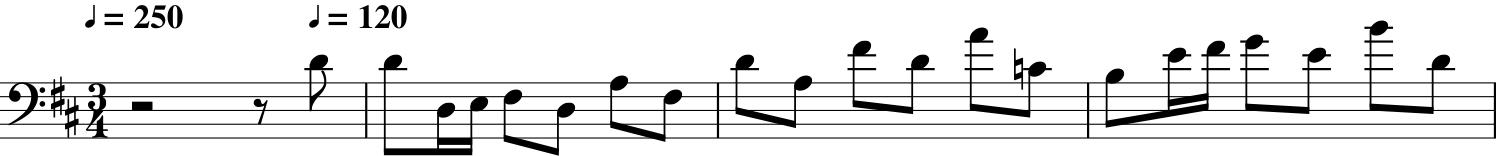

In [45]:
example_score.show()

In [25]:
example_score.show("text")

{0.0} <music21.metadata.Metadata object at 0x78c0a06475c0>
{0.0} <music21.stream.Measure 1 offset=0.0>
    {0.0} <music21.instrument.Violoncello 'Solo Cello: Solo Cello'>
    {0.0} <music21.instrument.Violoncello 'Violoncello'>
    {0.0} <music21.clef.BassClef>
    {0.0} <music21.tempo.MetronomeMark Quarter=250>
    {0.0} <music21.key.Key of D major>
    {0.0} <music21.meter.TimeSignature 3/4>
    {0.0} <music21.note.Rest 2.5ql>
    {2.5} <music21.tempo.MetronomeMark animato Quarter=120>
    {2.5} <music21.chord.Chord D4>
{3.0} <music21.stream.Measure 2 offset=3.0>
    {0.0} <music21.chord.Chord D4>
    {0.5} <music21.chord.Chord D3>
    {0.75} <music21.chord.Chord E3>
    {1.0} <music21.chord.Chord F#3>
    {1.5} <music21.chord.Chord D3>
    {2.0} <music21.chord.Chord A3>
    {2.5} <music21.chord.Chord F#3>
{6.0} <music21.stream.Measure 3 offset=6.0>
    {0.0} <music21.chord.Chord D4>
    {0.5} <music21.chord.Chord A3>
    {1.0} <music21.chord.Chord F#4>
    {1.5} <music21.chord.Chord

In [48]:
if PARSE_MIDI_FILES:
    notes, durations = parse_midi_files(
        file_list, parser, SEQ_LEN + 1, PARSED_DATA_PATH
    )
else:
    # notes, durations = load_parsed_files()
    notes, durations = load_parsed_files(PARSED_DATA_PATH)


In [49]:
example_notes = notes[658]
example_durations = durations[658]
print("\nNotes string\n", example_notes, "...")
print("\nDuration string\n", example_durations, "...")


Notes string
 G#3 G3 G#3 B-3 G#3 G3 F3 E3 F3 G3 C3 D3 E3 F3 E3 F3 G3 F3 E3 F3 E-3 C#3 C3 C#3 E-3 C#3 E3 F3 G3 F3 E3 F3 C3 B-2 A2 B-2 C3 B-2 E3 F3 G3 F3 E3 B2 F3 G3 G#3 G3 F3 C4 B-3 ...

Duration string
 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 1/3 ...


## 2. Tokenize the data <a name="tokenize"></a>

In [50]:
def create_dataset(elements):
    ds = (
        tf.data.Dataset.from_tensor_slices(elements)
        .batch(BATCH_SIZE, drop_remainder=True)
        .shuffle(1000)
    )
    vectorize_layer = layers.TextVectorization(
        standardize=None, output_mode="int"
    )
    vectorize_layer.adapt(ds)
    vocab = vectorize_layer.get_vocabulary()
    return ds, vectorize_layer, vocab


notes_seq_ds, notes_vectorize_layer, notes_vocab = create_dataset(notes)
durations_seq_ds, durations_vectorize_layer, durations_vocab = create_dataset(
    durations
)
seq_ds = tf.data.Dataset.zip((notes_seq_ds, durations_seq_ds))

In [51]:
# Display the same example notes and durations converted to ints
example_tokenised_notes = notes_vectorize_layer(example_notes)
example_tokenised_durations = durations_vectorize_layer(example_durations)
print("{:10} {:10}".format("note token", "duration token"))
for i, (note_int, duration_int) in enumerate(
    zip(
        example_tokenised_notes.numpy()[:11],
        example_tokenised_durations.numpy()[:11],
    )
):
    print(f"{note_int:10}{duration_int:10}")

note token duration token
        14         5
         2         5
        14         5
        11         5
        14         5
         2         5
         5         5
         8         5
         5         5
         2         5
        13         5


In [52]:
notes_vocab_size = len(notes_vocab)
durations_vocab_size = len(durations_vocab)

# Display some token:note mappings
print(f"\nNOTES_VOCAB: length = {len(notes_vocab)}")
for i, note in enumerate(notes_vocab[:10]):
    print(f"{i}: {note}")

print(f"\nDURATIONS_VOCAB: length = {len(durations_vocab)}")
# Display some token:duration mappings
for i, note in enumerate(durations_vocab[:10]):
    print(f"{i}: {note}")


NOTES_VOCAB: length = 59
0: 
1: [UNK]
2: G3
3: A3
4: D3
5: F3
6: C4
7: D4
8: E3
9: B3

DURATIONS_VOCAB: length = 24
0: 
1: [UNK]
2: 0.25
3: 0.5
4: 1.0
5: 1/3
6: 0.75
7: 1/12
8: 1.5
9: 0.0


## 3. Create the Training Set <a name="create"></a>

In [53]:
# Create the training set of sequences and the same sequences shifted by one note
def prepare_inputs(notes, durations):
    notes = tf.expand_dims(notes, -1)
    durations = tf.expand_dims(durations, -1)
    tokenized_notes = notes_vectorize_layer(notes)
    tokenized_durations = durations_vectorize_layer(durations)
    x = (tokenized_notes[:, :-1], tokenized_durations[:, :-1])
    y = (tokenized_notes[:, 1:], tokenized_durations[:, 1:])
    return x, y


ds = seq_ds.map(prepare_inputs).repeat(DATASET_REPETITIONS)

In [54]:
example_input_output = ds.take(1).get_single_element()
print(example_input_output)

((<tf.Tensor: shape=(256, 50), dtype=int64, numpy=
array([[11,  9,  4, ..., 12,  8,  2],
       [ 9,  4,  8, ...,  8,  2, 12],
       [ 4,  8, 12, ...,  2, 12,  8],
       ...,
       [10, 20, 10, ...,  7, 11,  5],
       [20, 10, 16, ..., 11,  5, 11],
       [10, 16, 20, ...,  5, 11,  4]])>, <tf.Tensor: shape=(256, 50), dtype=int64, numpy=
array([[2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2],
       ...,
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2]])>), (<tf.Tensor: shape=(256, 50), dtype=int64, numpy=
array([[ 9,  4,  8, ...,  8,  2, 12],
       [ 4,  8, 12, ...,  2, 12,  8],
       [ 8, 12,  9, ..., 12,  8,  4],
       ...,
       [20, 10, 16, ..., 11,  5, 11],
       [10, 16, 20, ...,  5, 11,  4],
       [16, 20, 31, ..., 11,  4,  5]])>, <tf.Tensor: shape=(256, 50), dtype=int64, numpy=
array([[2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2],
       [2, 2, 2, ..., 2, 2, 2],
       ...,

## 5. Create the causal attention mask function <a name="causal"></a>

In [55]:
def causal_attention_mask(batch_size, n_dest, n_src, dtype):
    i = tf.range(n_dest)[:, None]
    j = tf.range(n_src)
    m = i >= j - n_src + n_dest
    mask = tf.cast(m, dtype)
    mask = tf.reshape(mask, [1, n_dest, n_src])
    mult = tf.concat(
        [tf.expand_dims(batch_size, -1), tf.constant([1, 1], dtype=tf.int32)], 0
    )
    return tf.tile(mask, mult)


np.transpose(causal_attention_mask(1, 10, 10, dtype=tf.int32)[0])

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 1, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]], dtype=int32)

## 6. Create a Transformer Block layer <a name="transformer"></a>

In [56]:
class TransformerBlock(layers.Layer):
    def __init__(
        self,
        num_heads,
        key_dim,
        embed_dim,
        ff_dim,
        name,
        dropout_rate=DROPOUT_RATE,
    ):
        super(TransformerBlock, self).__init__(name=name)
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.embed_dim = embed_dim
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate
        self.attn = layers.MultiHeadAttention(
            num_heads, key_dim, output_shape=embed_dim
        )
        self.dropout_1 = layers.Dropout(self.dropout_rate)
        self.ln_1 = layers.LayerNormalization(epsilon=1e-6)
        self.ffn_1 = layers.Dense(self.ff_dim, activation="relu")
        self.ffn_2 = layers.Dense(self.embed_dim)
        self.dropout_2 = layers.Dropout(self.dropout_rate)
        self.ln_2 = layers.LayerNormalization(epsilon=1e-6)

    def call(self, inputs):
        input_shape = tf.shape(inputs)
        batch_size = input_shape[0]
        seq_len = input_shape[1]
        causal_mask = causal_attention_mask(
            batch_size, seq_len, seq_len, tf.bool
        )
        attention_output, attention_scores = self.attn(
            inputs,
            inputs,
            attention_mask=causal_mask,
            return_attention_scores=True,
        )
        attention_output = self.dropout_1(attention_output)
        out1 = self.ln_1(inputs + attention_output)
        ffn_1 = self.ffn_1(out1)
        ffn_2 = self.ffn_2(ffn_1)
        ffn_output = self.dropout_2(ffn_2)
        return (self.ln_2(out1 + ffn_output), attention_scores)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "key_dim": self.key_dim,
                "embed_dim": self.embed_dim,
                "num_heads": self.num_heads,
                "ff_dim": self.ff_dim,
                "dropout_rate": self.dropout_rate,
            }
        )
        return config

## 7. Create the Token and Position Embedding <a name="embedder"></a>

In [57]:
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.token_emb = layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim,
            embeddings_initializer="he_uniform",
        )
        self.pos_emb = SinePositionEncoding()

    def call(self, x):
        embedding = self.token_emb(x)
        positions = self.pos_emb(embedding)
        return embedding + positions

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "vocab_size": self.vocab_size,
                "embed_dim": self.embed_dim,
            }
        )
        return config

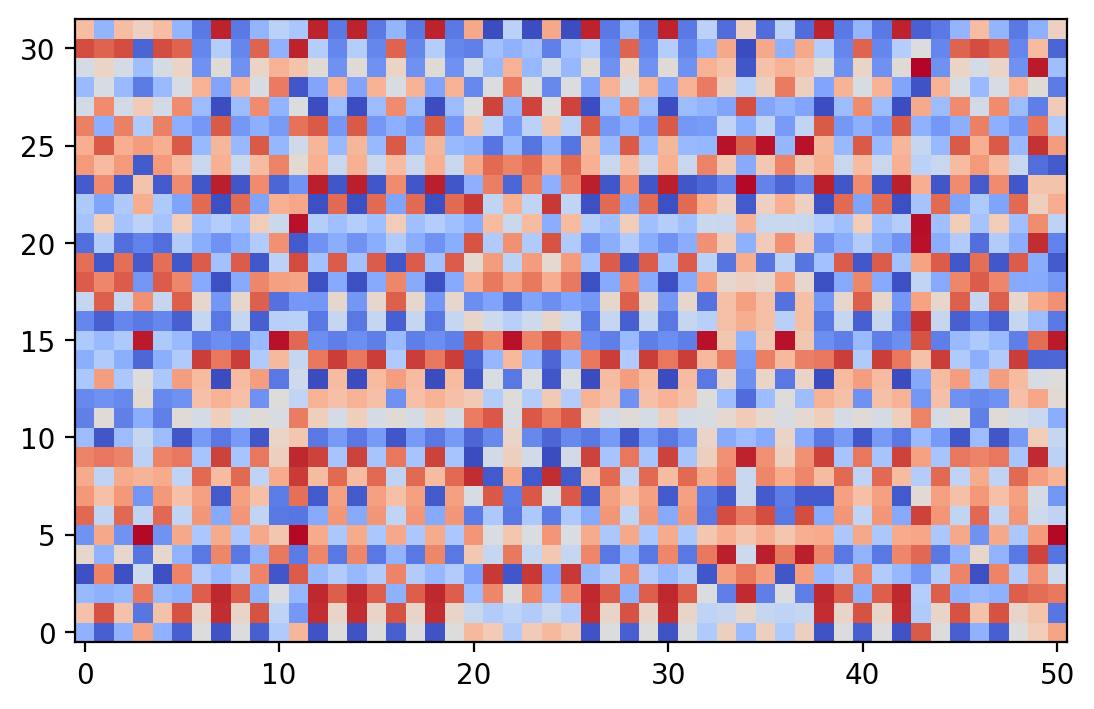

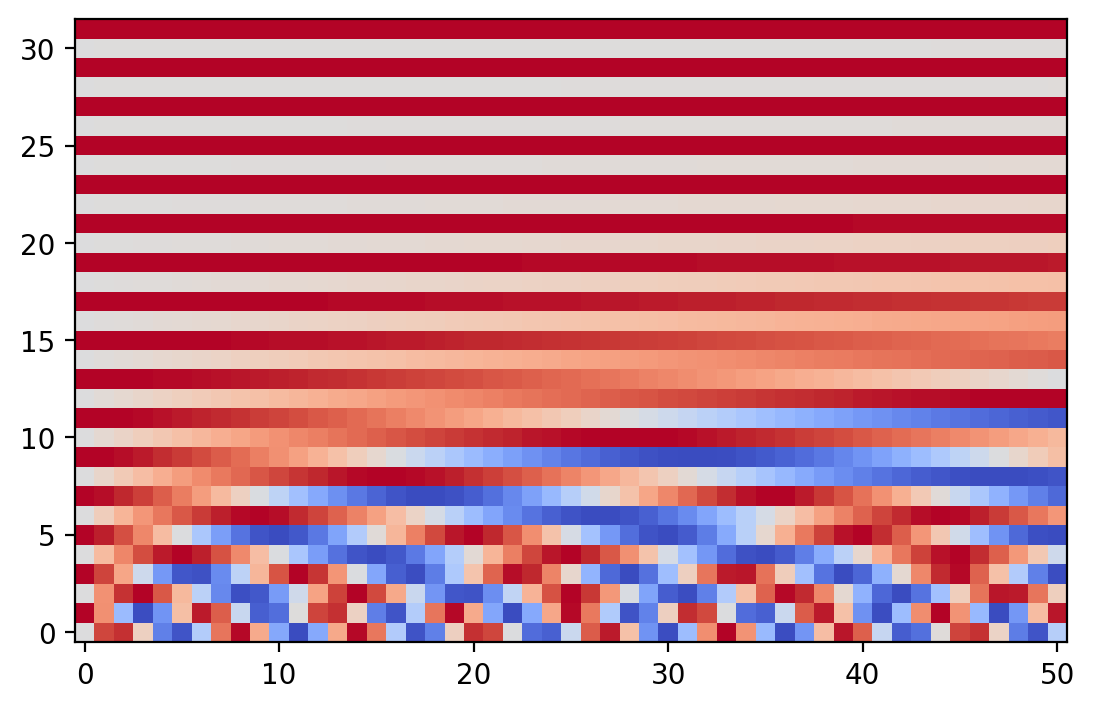

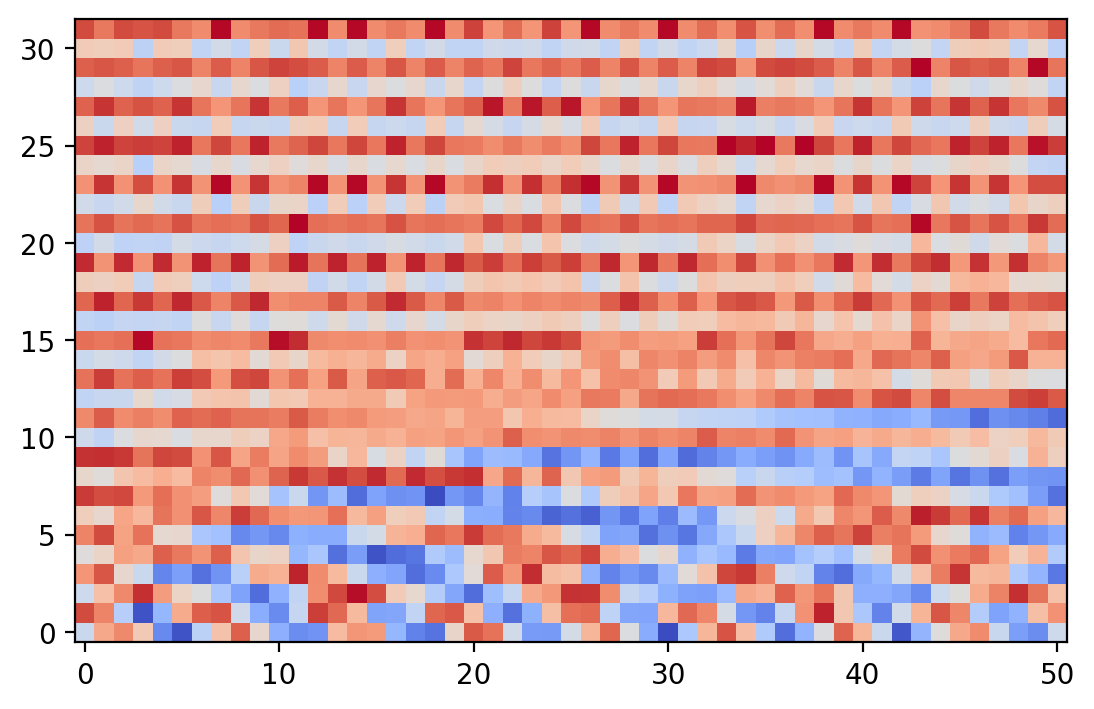

In [58]:
tpe = TokenAndPositionEmbedding(notes_vocab_size, 32)
token_embedding = tpe.token_emb(example_tokenised_notes)
position_embedding = tpe.pos_emb(token_embedding)
embedding = tpe(example_tokenised_notes)
plt.imshow(
    np.transpose(token_embedding),
    cmap="coolwarm",
    interpolation="nearest",
    origin="lower",
)
plt.show()
plt.imshow(
    np.transpose(position_embedding),
    cmap="coolwarm",
    interpolation="nearest",
    origin="lower",
)
plt.show()
plt.imshow(
    np.transpose(embedding),
    cmap="coolwarm",
    interpolation="nearest",
    origin="lower",
)
plt.show()

## 8. Build the Transformer model <a name="transformer_decoder"></a>

In [59]:
note_inputs = layers.Input(shape=(None,), dtype=tf.int32)
durations_inputs = layers.Input(shape=(None,), dtype=tf.int32)
note_embeddings = TokenAndPositionEmbedding(
    notes_vocab_size, EMBEDDING_DIM // 2
)(note_inputs)
duration_embeddings = TokenAndPositionEmbedding(
    durations_vocab_size, EMBEDDING_DIM // 2
)(durations_inputs)
embeddings = layers.Concatenate()([note_embeddings, duration_embeddings])
x, attention_scores = TransformerBlock(
    N_HEADS, KEY_DIM, EMBEDDING_DIM, FEED_FORWARD_DIM, name="attention"
)(embeddings)
note_outputs = layers.Dense(
    notes_vocab_size, activation="softmax", name="note_outputs"
)(x)
duration_outputs = layers.Dense(
    durations_vocab_size, activation="softmax", name="duration_outputs"
)(x)
model = models.Model(
    inputs=[note_inputs, durations_inputs],
    outputs=[note_outputs, duration_outputs],  # attention_scores
)
model.compile(
    "adam",
    loss=[
        losses.SparseCategoricalCrossentropy(),
        losses.SparseCategoricalCrossentropy(),
    ],
)
att_model = models.Model(
    inputs=[note_inputs, durations_inputs], outputs=attention_scores
)

In [60]:
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, None, 128) │      7,552 │ input_layer_2[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ (None, None, 128) │      3,072 │ input_layer_3[0]… │
│ (TokenAndPositionE… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, None, 256) │          0 │ token_and_positi… │
│ (Concatenate)       │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ [(None, None,     │  1,447,424 │ concatenate_1[0]… │
│ (TransformerBlock)  │ 256), (None, 5,   │            │                   │
│                     │ None, None)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ note_outputs        │ (None, None, 59)  │     15,163 │ attention[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ duration_outputs    │ (None, None, 24)  │      6,168 │ attention[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,479,379 (5.64 MB)

 Trainable params: 1,479,379 (5.64 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
if LOAD_MODEL:
    model.load_weights("./checkpoint/checkpoint.ckpt")
    # model = models.load_model('./models/model', compile=True)

## 9. Train the Transformer <a name="train"></a>

In [62]:
# Create a MusicGenerator checkpoint
class MusicGenerator(callbacks.Callback):
    def __init__(self, index_to_note, index_to_duration, top_k=10):
        self.index_to_note = index_to_note
        self.note_to_index = {
            note: index for index, note in enumerate(index_to_note)
        }
        self.index_to_duration = index_to_duration
        self.duration_to_index = {
            duration: index for index, duration in enumerate(index_to_duration)
        }

    def sample_from(self, probs, temperature):
        probs = probs ** (1 / temperature)
        probs = probs / np.sum(probs)
        return np.random.choice(len(probs), p=probs), probs

    def get_note(self, notes, durations, temperature):
        sample_note_idx = 1
        while sample_note_idx == 1:
            sample_note_idx, note_probs = self.sample_from(
                notes[0][-1], temperature
            )
            sample_note = self.index_to_note[sample_note_idx]

        sample_duration_idx = 1
        while sample_duration_idx == 1:
            sample_duration_idx, duration_probs = self.sample_from(
                durations[0][-1], temperature
            )
            sample_duration = self.index_to_duration[sample_duration_idx]

        new_note = get_midi_note(sample_note, sample_duration)

        return (
            new_note,
            sample_note_idx,
            sample_note,
            note_probs,
            sample_duration_idx,
            sample_duration,
            duration_probs,
        )

    def generate(self, start_notes, start_durations, max_tokens, temperature):
        attention_model = models.Model(
            inputs=self.model.input,
            outputs=self.model.get_layer("attention").output,
        )

        start_note_tokens = [self.note_to_index.get(x, 1) for x in start_notes]
        start_duration_tokens = [
            self.duration_to_index.get(x, 1) for x in start_durations
        ]
        sample_note = None
        sample_duration = None
        info = []
        midi_stream = music21.stream.Stream()

        midi_stream.append(music21.clef.BassClef())

        for sample_note, sample_duration in zip(start_notes, start_durations):
            new_note = get_midi_note(sample_note, sample_duration)
            if new_note is not None:
                midi_stream.append(new_note)

        while len(start_note_tokens) < max_tokens:
            x1 = np.array([start_note_tokens])
            x2 = np.array([start_duration_tokens])
            notes, durations = self.model.predict([x1, x2], verbose=0)

            repeat = True

            while repeat:
                (
                    new_note,
                    sample_note_idx,
                    sample_note,
                    note_probs,
                    sample_duration_idx,
                    sample_duration,
                    duration_probs,
                ) = self.get_note(notes, durations, temperature)

                if (
                    isinstance(new_note, music21.chord.Chord)
                    or isinstance(new_note, music21.note.Note)
                    or isinstance(new_note, music21.note.Rest)
                ) and sample_duration == "0.0":
                    repeat = True
                else:
                    repeat = False

            if new_note is not None:
                midi_stream.append(new_note)

            _, att = attention_model.predict([x1, x2], verbose=0)

            info.append(
                {
                    "prompt": [start_notes.copy(), start_durations.copy()],
                    "midi": midi_stream,
                    "chosen_note": (sample_note, sample_duration),
                    "note_probs": note_probs,
                    "duration_probs": duration_probs,
                    "atts": att[0, :, -1, :],
                }
            )
            start_note_tokens.append(sample_note_idx)
            start_duration_tokens.append(sample_duration_idx)
            start_notes.append(sample_note)
            start_durations.append(sample_duration)

            if sample_note == "START":
                break

        return info

    def on_epoch_end(self, epoch, logs=None):
        info = self.generate(
            ["START"], ["0.0"], max_tokens=GENERATE_LEN, temperature=0.5
        )
        midi_stream = info[-1]["midi"].chordify()
        print(info[-1]["prompt"])
        midi_stream.show()
        midi_stream.write(
            "midi",
            fp=os.path.join(
                # "/app/notebooks/11_music/01_transformer/output",
                OUTPUT_DIR,
                "output-" + str(epoch).zfill(4) + ".mid",
            ),
        )

In [65]:
# Create a model save checkpoint
model_checkpoint_callback = callbacks.ModelCheckpoint(
    filepath="./checkpoint/checkpoint.weights.h5",
    save_weights_only=True,
    save_freq="epoch",
    verbose=0,
)

tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")

# Tokenize starting prompt
music_generator = MusicGenerator(notes_vocab, durations_vocab)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 1.4144 - loss: 5.0250 - note_outputs_loss: 3.6107

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 5, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


[['START', np.str_('E3'), np.str_('D3'), np.str_('D3'), np.str_('E3'), np.str_('D3'), np.str_('E-3'), np.str_('D3'), np.str_('E3'), np.str_('D3'), np.str_('E-3'), np.str_('D3'), np.str_('F3'), np.str_('E3'), np.str_('F3'), np.str_('F3'), np.str_('G3'), np.str_('F3'), np.str_('D3'), np.str_('F3'), np.str_('G3'), np.str_('F3'), np.str_('F3'), np.str_('E3'), np.str_('D3'), np.str_('E3'), np.str_('D3'), np.str_('F3'), np.str_('E3'), np.str_('F3'), np.str_('G3'), np.str_('F3'), np.str_('G3'), np.str_('F3'), np.str_('F3'), np.str_('B-3'), np.str_('A3'), np.str_('G3'), np.str_('G#3'), np.str_('G3'), np.str_('G2'), np.str_('G3'), np.str_('F3'), np.str_('D3'), np.str_('E3'), np.str_('D3'), np.str_('F3'), np.str_('G3'), np.str_('F3')], ['0.0', np.str_('1.0'), np.str_('1.0'), np.str_('1.0'), np.str_('1.0'), np.str_('1.0'), np.str_('1.0'), np.str_('1.0'), np.str_('1.0'), np.str_('1.0'), np.str_('1.0'), np.str_('1.0'), np.str_('1.0'), np.str_('1.0'), np.str_('1.0'), np.str_('1.0'), np.str_('0.5'), 

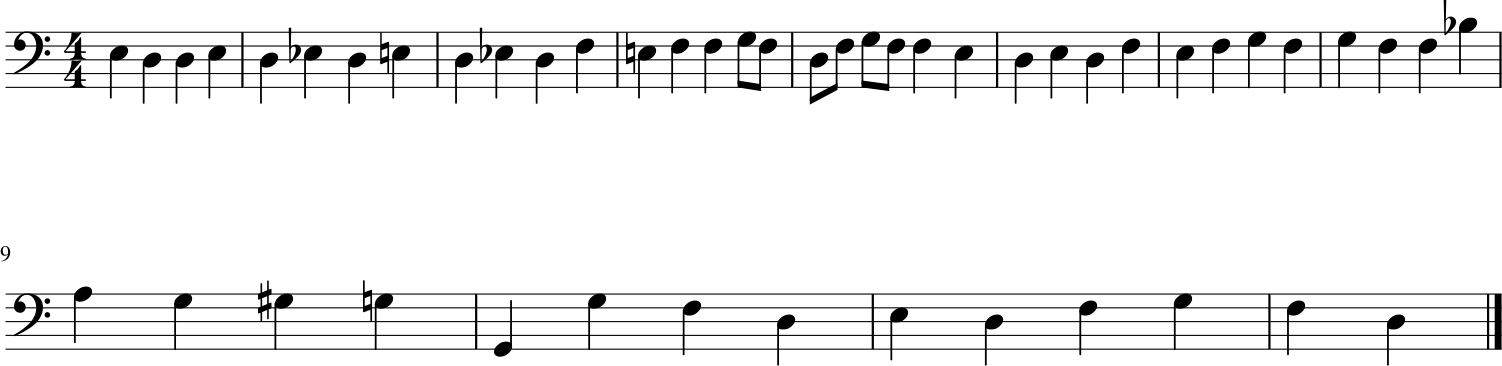

107/107 ━━━━━━━━━━━━━━━━━━━━ 164s 1s/step - duration_outputs_loss: 0.9613 - loss: 4.2927 - note_outputs_loss: 3.3313
Epoch 2/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.6752 - loss: 3.4810 - note_outputs_loss: 2.8058[['START', np.str_('A3'), np.str_('B3'), np.str_('F#3'), np.str_('G3'), np.str_('F#3'), np.str_('G3'), np.str_('F#3'), np.str_('E3'), np.str_('D3'), np.str_('E3'), np.str_('F#3'), np.str_('G3'), np.str_('F#3'), np.str_('E3'), np.str_('F#3'), np.str_('E3'), np.str_('D3'), np.str_('C#3'), np.str_('B2'), np.str_('C#3'), np.str_('D3'), np.str_('E3'), np.str_('C#3'), np.str_('B2'), np.str_('C#3'), np.str_('E3'), np.str_('F#3'), np.str_('E3'), np.str_('F#3'), np.str_('G3'), np.str_('F#3'), np.str_('G3'), np.str_('E3'), np.str_('F#3'), np.str_('G3'), np.str_('F#3'), np.str_('E3'), np.str_('F#3'), np.str_('G3'), np.str_('F#3'), np.str_('E3'), np.str_('F#3'), np.str_('G3'), np.str_('F#3'), np.str_('E3'), np.str_('F#3'), np.str_('A3'), np.str_('F#3')], ['0.

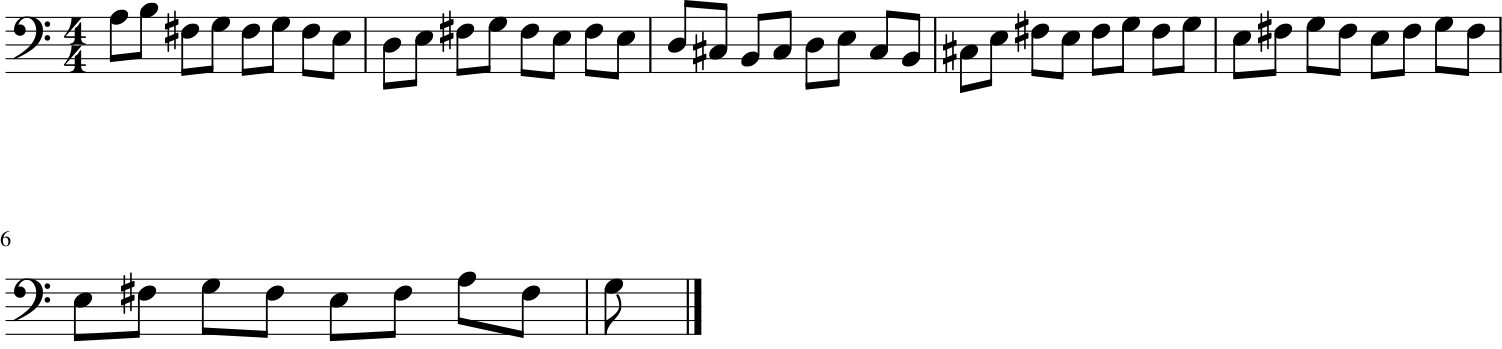

107/107 ━━━━━━━━━━━━━━━━━━━━ 71s 673ms/step - duration_outputs_loss: 0.6816 - loss: 3.4151 - note_outputs_loss: 2.7335
Epoch 3/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.6201 - loss: 3.1732 - note_outputs_loss: 2.5531[['START', np.str_('E-:major'), np.str_('A3'), np.str_('A3'), np.str_('A3'), np.str_('A3'), np.str_('F#3'), np.str_('A3'), np.str_('A3'), np.str_('A3'), np.str_('B3'), np.str_('C4'), np.str_('D4'), np.str_('A3'), np.str_('B3'), np.str_('A3'), np.str_('G3'), np.str_('F#3'), np.str_('G3'), np.str_('F#3'), np.str_('G3'), np.str_('A3'), np.str_('F#3'), np.str_('G3'), np.str_('F#3'), np.str_('G3'), np.str_('F#3'), np.str_('G3'), np.str_('F#3'), np.str_('G3'), np.str_('F#3'), np.str_('G3'), np.str_('D3'), np.str_('E3'), np.str_('G3'), np.str_('E3'), np.str_('F#3'), np.str_('G3'), np.str_('F#3'), np.str_('G3'), np.str_('F#3'), np.str_('G3'), np.str_('E3'), np.str_('F#3'), np.str_('E3'), np.str_('G3'), np.str_('F#3'), np.str_('G3'), np.str_('F#3')], ['0

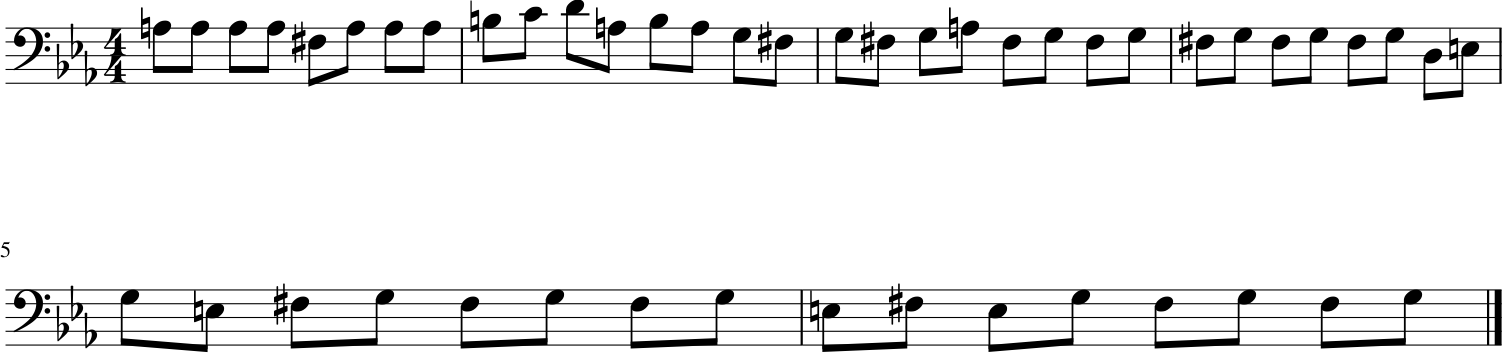

107/107 ━━━━━━━━━━━━━━━━━━━━ 71s 667ms/step - duration_outputs_loss: 0.5961 - loss: 3.1620 - note_outputs_loss: 2.5660
Epoch 4/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.5723 - loss: 3.0172 - note_outputs_loss: 2.4449[['START', np.str_('3/4TS'), np.str_('rest')], ['0.0', np.str_('0.0'), np.str_('1.0')]]


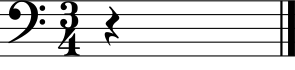

107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - duration_outputs_loss: 0.5918 - loss: 3.0572 - note_outputs_loss: 2.4654
Epoch 5/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.5667 - loss: 2.9473 - note_outputs_loss: 2.3805

[['START', np.str_('E-:major'), np.str_('3/4TS'), np.str_('3/4TS'), np.str_('rest'), np.str_('D4'), np.str_('C4'), np.str_('B-3'), np.str_('G#3'), np.str_('G3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('G3'), np.str_('E-3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('F3'), np.str_('G3'), np.str_('E-3'), np.str_('F3'), np.str_('G3'), np.str_('F3'), np.str_('G3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('C3'), np.str_('B-2'), np.str_('G#2')], ['0.0', np.str_('0.0'), np.str_('0.0'), np.str_('0.0'), np.str_('3.75'), np.str_('0.25'), np.str_('0.25'), np.str_('0.25'), np.str_('0.25'), np.str_('0.25'), np.str_('0.25'), np.str_('0.25'), np.str_('0.25'), np.str_('0.25'), np.str_('0

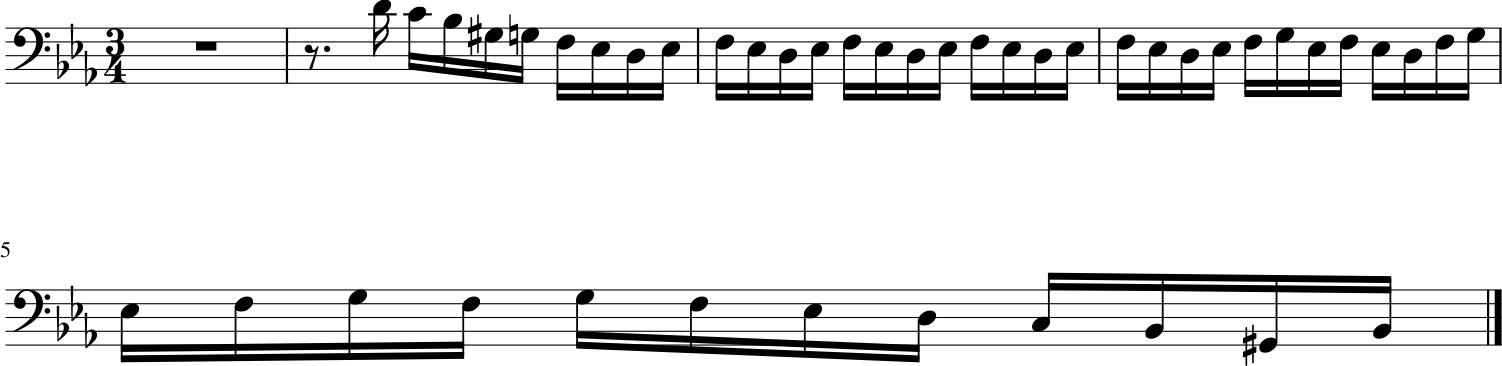

107/107 ━━━━━━━━━━━━━━━━━━━━ 71s 666ms/step - duration_outputs_loss: 0.6065 - loss: 3.0102 - note_outputs_loss: 2.4037
Epoch 6/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.5444 - loss: 2.9167 - note_outputs_loss: 2.3723[['START', np.str_('E-:major'), np.str_('3/4TS'), np.str_('rest'), np.str_('D4'), np.str_('C4'), np.str_('B-3'), np.str_('G#3'), np.str_('G3'), np.str_('G#3'), np.str_('B-3'), np.str_('G3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('C3'), np.str_('E-3'), np.str_('D3'), np.str_('C3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('G3'), np.str_('G#3'), np.str_('G3'), np.str_('F3'), np.str_('E-3'), np.str_('G3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('C3'), np.str_('D3'), np.str_('E-3'), np.str_('D

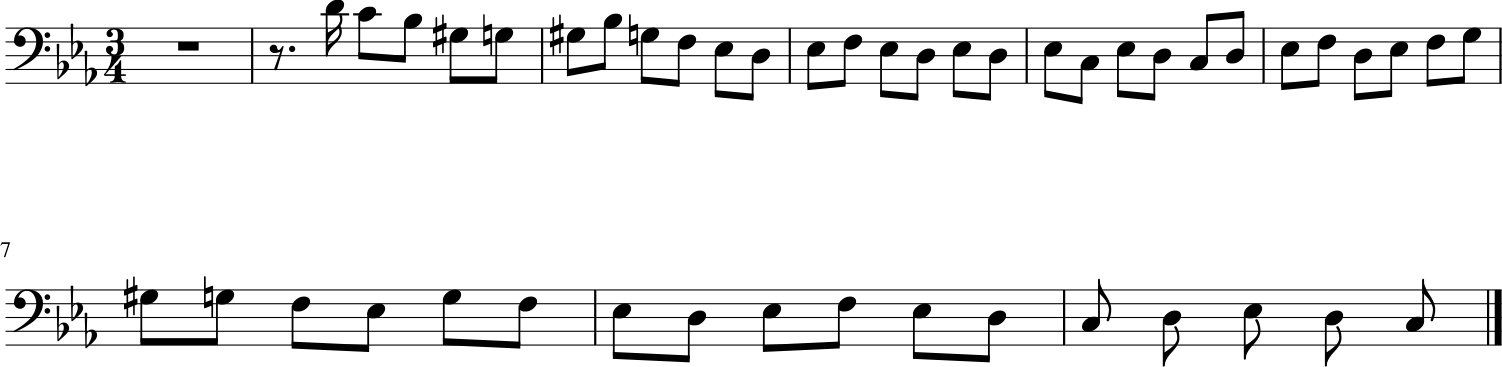

107/107 ━━━━━━━━━━━━━━━━━━━━ 71s 667ms/step - duration_outputs_loss: 0.5750 - loss: 2.9375 - note_outputs_loss: 2.3625
Epoch 7/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.5927 - loss: 2.8714 - note_outputs_loss: 2.2787[['START', np.str_('G:major'), np.str_('3/4TS'), np.str_('rest'), np.str_('D4'), np.str_('C4'), np.str_('C4'), np.str_('B3'), np.str_('A3'), np.str_('B3'), np.str_('C4'), np.str_('B3'), np.str_('C4'), np.str_('A3'), np.str_('B3'), np.str_('A3'), np.str_('G3'), np.str_('A3'), np.str_('B3'), np.str_('C4'), np.str_('B3'), np.str_('A3'), np.str_('B3'), np.str_('C4'), np.str_('B3'), np.str_('A3'), np.str_('B3'), np.str_('C4'), np.str_('D4'), np.str_('E4'), np.str_('D4'), np.str_('B3'), np.str_('C4'), np.str_('A3'), np.str_('B3'), np.str_('A3'), np.str_('G#3'), np.str_('A3'), np.str_('B3'), np.str_('C4'), np.str_('A3'), np.str_('B3'), np.str_('A3'), np.str_('B3'), np.str_('C4'), np.str_('D4'), np.str_('A3'), np.str_('E3'), np.str_('F#3')], ['0.0', np.

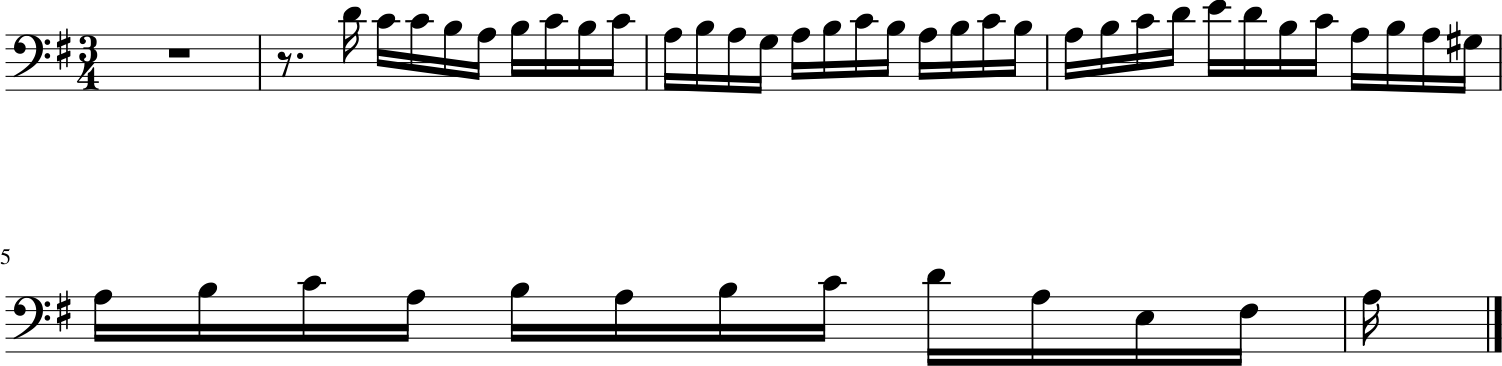

107/107 ━━━━━━━━━━━━━━━━━━━━ 71s 671ms/step - duration_outputs_loss: 0.5694 - loss: 2.8766 - note_outputs_loss: 2.3072
Epoch 8/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.5453 - loss: 2.8344 - note_outputs_loss: 2.2891[['START', np.str_('F:major'), np.str_('3/4TS'), np.str_('B-3'), np.str_('A3'), np.str_('F3'), np.str_('D4'), np.str_('F3'), np.str_('E3'), np.str_('F3'), np.str_('A3'), np.str_('B-3'), np.str_('A3'), np.str_('G3'), np.str_('A3'), np.str_('F3'), np.str_('E3'), np.str_('F3'), np.str_('E3'), np.str_('F3'), np.str_('E3'), np.str_('D3'), np.str_('C3'), np.str_('C3'), np.str_('B2'), np.str_('A2'), np.str_('B2'), np.str_('C#3'), np.str_('E3'), np.str_('F3'), np.str_('D3'), np.str_('E3'), np.str_('F3'), np.str_('E3'), np.str_('F3'), np.str_('G3'), np.str_('A3'), np.str_('B-3'), np.str_('A3'), np.str_('G3'), np.str_('A3'), np.str_('F3'), np.str_('E3'), np.str_('D3'), np.str_('E3'), np.str_('F3'), np.str_('G3'), np.str_('A3'), np.str_('B-3')], ['0.0', np

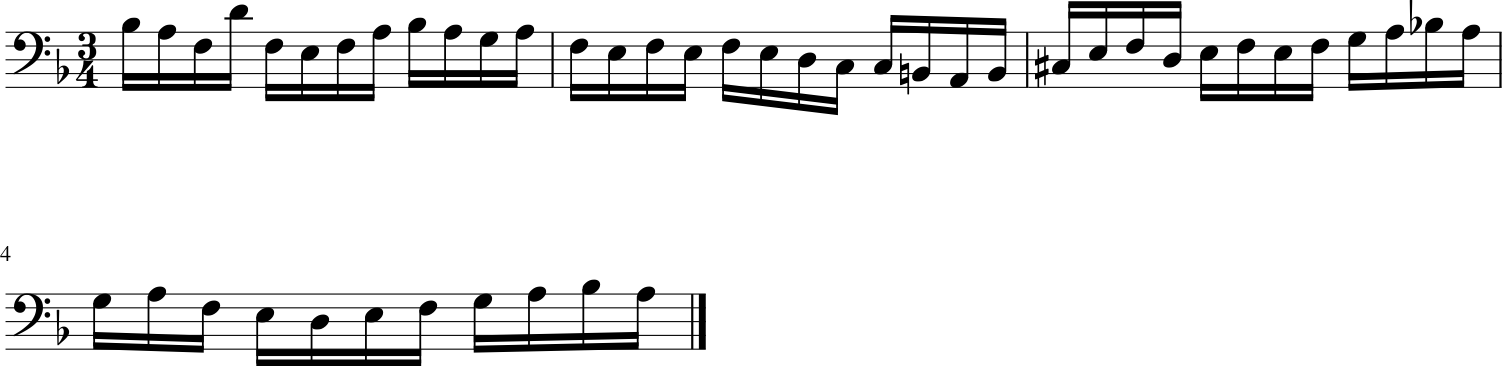

107/107 ━━━━━━━━━━━━━━━━━━━━ 71s 672ms/step - duration_outputs_loss: 0.5615 - loss: 2.8280 - note_outputs_loss: 2.2665
Epoch 9/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.5690 - loss: 2.8212 - note_outputs_loss: 2.2521[['START', np.str_('E-:major'), np.str_('3/4TS'), np.str_('rest'), np.str_('E-3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('G#3'), np.str_('F3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('C3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('C3'), np.str_('B-2'), np.str_('G#2'), np.str_('G2'), np.str_('G#2'), np.str_('G2'), np.str_('G#2'), np.str_('C3'), np.str_('D3'), np.str_('E-3'), np.str_('G#2'), np.str_('G2'), np.str_('G#2'), np.str_('G2'), np.str_('G#2'), np.str_('G2'), np.str_('G#2'), np.str_('B-2'), np.str_('G#2'), np.str_('G2'), np.str_('G#2'), np.str

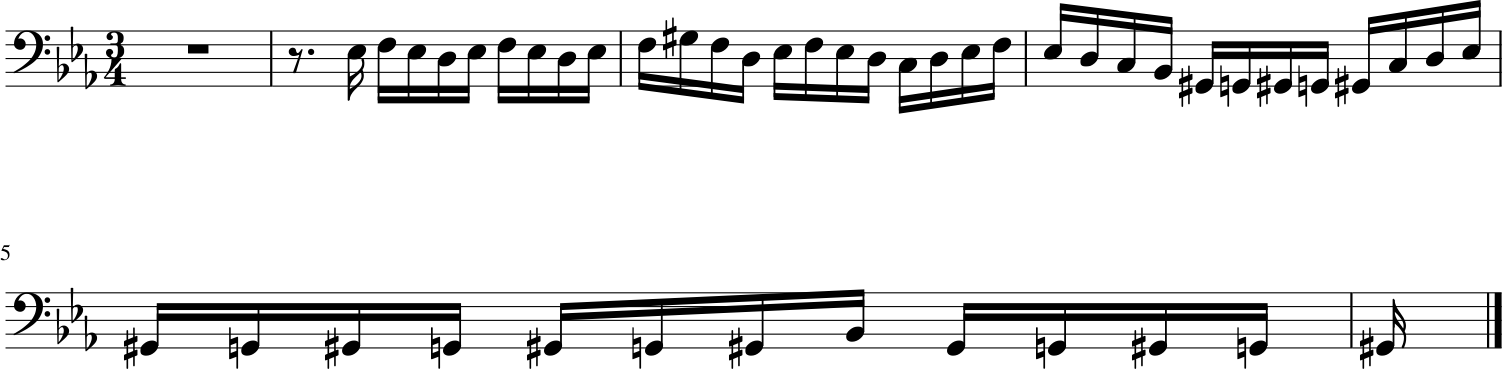

107/107 ━━━━━━━━━━━━━━━━━━━━ 72s 675ms/step - duration_outputs_loss: 0.5639 - loss: 2.7950 - note_outputs_loss: 2.2310
Epoch 10/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.5804 - loss: 2.7699 - note_outputs_loss: 2.1895[['START', np.str_('E-:major'), np.str_('4/4TS'), np.str_('rest'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('D3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('G3'), np.str_('E-3'), np.str_('D3'), np.str_('C3'), np.str_('D3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('D3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('B-3'), np.str_('D3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('G3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('D3'), np.str_

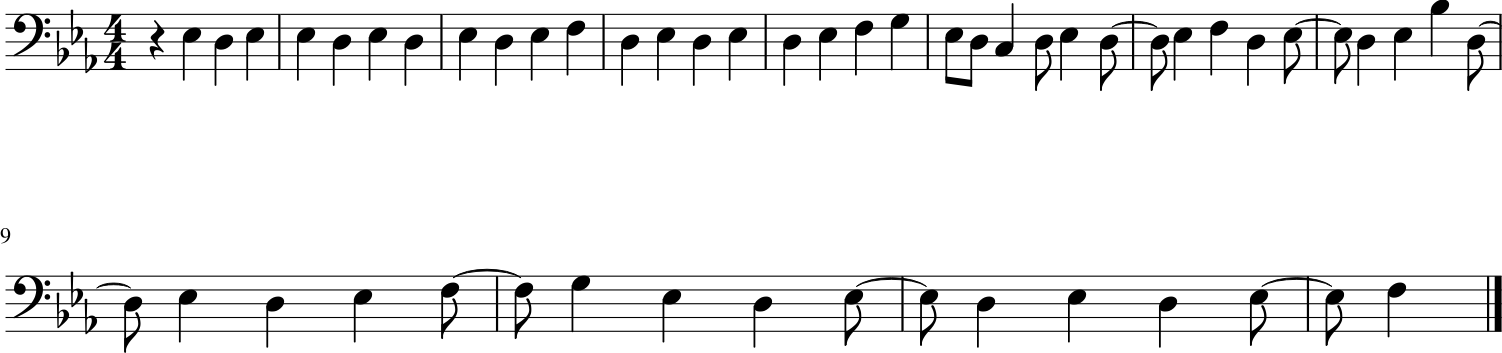

107/107 ━━━━━━━━━━━━━━━━━━━━ 70s 662ms/step - duration_outputs_loss: 0.5510 - loss: 2.7516 - note_outputs_loss: 2.2006
Epoch 11/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.5171 - loss: 2.6533 - note_outputs_loss: 2.1362[['START', np.str_('G:major'), np.str_('3/4TS'), np.str_('rest'), np.str_('B3'), np.str_('D3'), np.str_('B3'), np.str_('A3'), np.str_('B3'), np.str_('G2'), np.str_('B3'), np.str_('B3'), np.str_('G3'), np.str_('B3'), np.str_('D3'), np.str_('G2'), np.str_('B3'), np.str_('G2'), np.str_('G2'), np.str_('B3'), np.str_('C4'), np.str_('B3'), np.str_('A3'), np.str_('G3'), np.str_('B3'), np.str_('B3'), np.str_('A3'), np.str_('G3'), np.str_('B3'), np.str_('G2'), np.str_('E3'), np.str_('G2'), np.str_('E3'), np.str_('G2'), np.str_('E3'), np.str_('G2'), np.str_('F#3'), np.str_('G2'), np.str_('E3'), np.str_('G2'), np.str_('E3'), np.str_('G2'), np.str_('E3'), np.str_('G2'), np.str_('E3'), np.str_('G2'), np.str_('E3'), np.str_('G2'), np.str_('E3')], ['0.0', np.

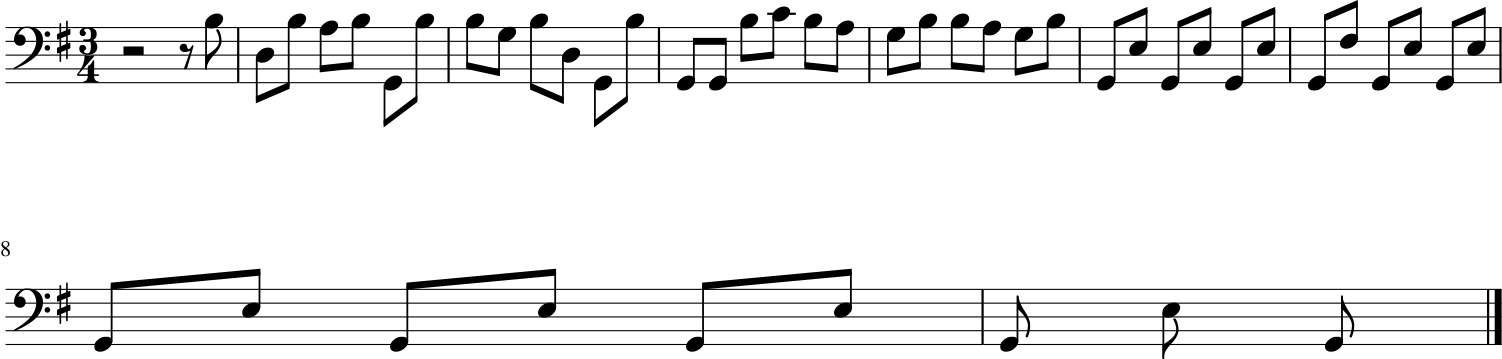

107/107 ━━━━━━━━━━━━━━━━━━━━ 70s 661ms/step - duration_outputs_loss: 0.5495 - loss: 2.7204 - note_outputs_loss: 2.1709
Epoch 12/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.5792 - loss: 2.7741 - note_outputs_loss: 2.1949[['START', np.str_('D:major'), np.str_('4/4TS'), np.str_('rest'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3')], ['0.0', np.s

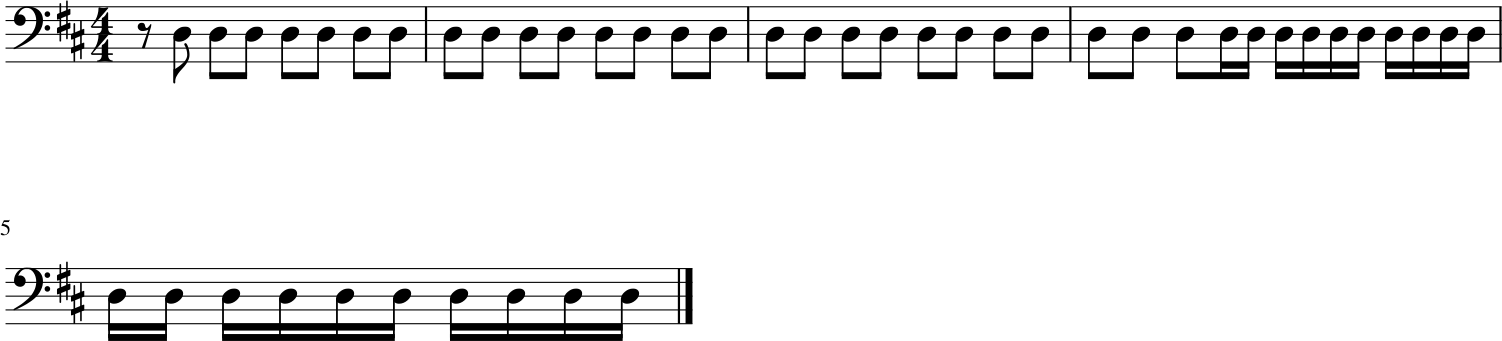

107/107 ━━━━━━━━━━━━━━━━━━━━ 70s 662ms/step - duration_outputs_loss: 0.5429 - loss: 2.6956 - note_outputs_loss: 2.1527
Epoch 13/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.5835 - loss: 2.6257 - note_outputs_loss: 2.0422[['START', np.str_('E-:major'), np.str_('3/4TS'), np.str_('B-3'), np.str_('G3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('G3'), np.str_('E-3'), np.str_('F3'), np.str_('G3'), np.str_('G#3'), np.str_('G3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('G3'), np.str_('B-3'), np.str_('G#3'), np.str_('G3'), np.str_('F3'), np.str_('G3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('G3'), np.str_('G#3'), np.str_('G3'), np.str_('F3'), np.str_('G3'), np.str_('G#3'), np.str_('B-3'), np.str_('B-3'), np.str_('G3'), np.str_('B-3'), np.str_('G#3'), np.str_('G

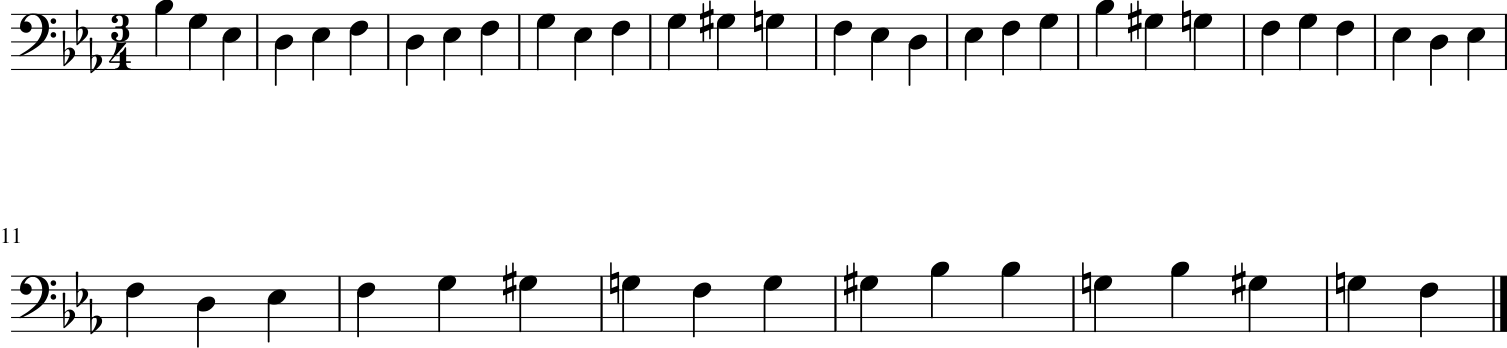

107/107 ━━━━━━━━━━━━━━━━━━━━ 70s 660ms/step - duration_outputs_loss: 0.5705 - loss: 2.6921 - note_outputs_loss: 2.1216
Epoch 14/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.5286 - loss: 2.5939 - note_outputs_loss: 2.0653[['START', np.str_('G:major'), np.str_('4/4TS'), np.str_('rest'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3'), np.str_('D3')], ['0.0', np.s

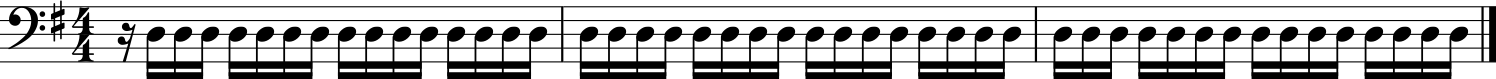

107/107 ━━━━━━━━━━━━━━━━━━━━ 70s 659ms/step - duration_outputs_loss: 0.5532 - loss: 2.6438 - note_outputs_loss: 2.0906
Epoch 15/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.5168 - loss: 2.5266 - note_outputs_loss: 2.0097[['START', np.str_('G:major'), np.str_('4/4TS'), np.str_('rest'), np.str_('D3'), np.str_('G3'), np.str_('D3'), np.str_('D3'), np.str_('G2'), np.str_('D3'), np.str_('G2'), np.str_('D3'), np.str_('G2'), np.str_('D3'), np.str_('G2'), np.str_('D3'), np.str_('G2'), np.str_('D3'), np.str_('G2'), np.str_('B3'), np.str_('G2'), np.str_('B3'), np.str_('G2'), np.str_('B3'), np.str_('A3'), np.str_('G3'), np.str_('A3'), np.str_('B3'), np.str_('C4'), np.str_('A3'), np.str_('G2'), np.str_('A3'), np.str_('E3'), np.str_('C3'), np.str_('E3'), np.str_('A3'), np.str_('C4'), np.str_('A3'), np.str_('A3'), np.str_('C4'), np.str_('A3'), np.str_('A3'), np.str_('G3'), np.str_('A3'), np.str_('B3'), np.str_('C4'), np.str_('A3'), np.str_('A3'), np.str_('B3')], ['0.0', np.s

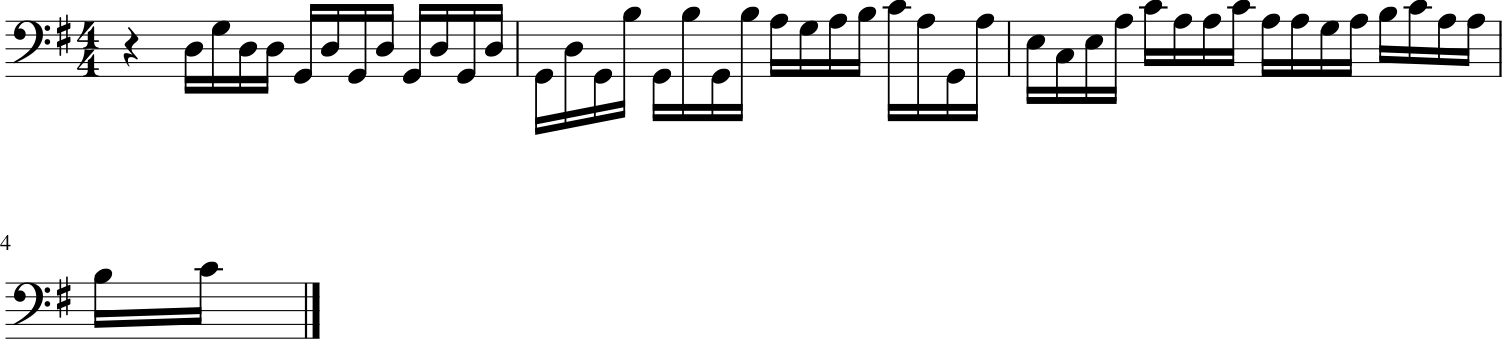

107/107 ━━━━━━━━━━━━━━━━━━━━ 72s 678ms/step - duration_outputs_loss: 0.5454 - loss: 2.6156 - note_outputs_loss: 2.0702
Epoch 16/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.5387 - loss: 2.5653 - note_outputs_loss: 2.0266[['START', np.str_('E-:major'), np.str_('4/4TS'), np.str_('rest'), np.str_('B-3'), np.str_('G3'), np.str_('G#3'), np.str_('F3'), np.str_('G3'), np.str_('E-3'), np.str_('G3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('C3'), np.str_('E-3'), np.str_('B-2'), np.str_('G#2'), np.str_('B-2'), np.str_('C3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('E-3'), np.str_('F3'), np.str_('G3'), np.str_('G#3'), np.str_('G3'), np.str_('F3'), np.str_('E-3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('B-2'), np.str_('C3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('G3'), np.str_('G#3'), np.str_('F3'), np.str_('G3'), np.str_('G#3'), np.str_('B-3'), np.str_('C4'), np.str_('G3'), np.str_

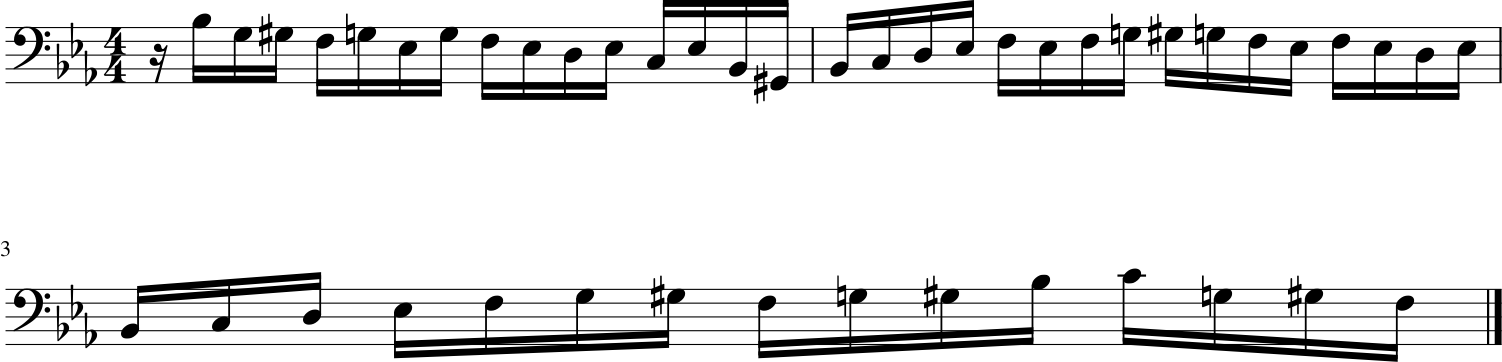

107/107 ━━━━━━━━━━━━━━━━━━━━ 70s 663ms/step - duration_outputs_loss: 0.5414 - loss: 2.5763 - note_outputs_loss: 2.0350
Epoch 17/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.5469 - loss: 2.5264 - note_outputs_loss: 1.9796[['START', np.str_('G:major'), np.str_('3/4TS'), np.str_('D3'), np.str_('E3'), np.str_('F#3'), np.str_('G3'), np.str_('A3'), np.str_('B3'), np.str_('A3'), np.str_('G3'), np.str_('F#3'), np.str_('E3'), np.str_('D3'), np.str_('E3'), np.str_('F#3'), np.str_('G3'), np.str_('A3'), np.str_('B3'), np.str_('C4'), np.str_('E3'), np.str_('F#3'), np.str_('G3'), np.str_('A3'), np.str_('B3'), np.str_('C4'), np.str_('B3'), np.str_('A3'), np.str_('G3'), np.str_('F#3'), np.str_('E3'), np.str_('D3'), np.str_('E3'), np.str_('B2'), np.str_('D3'), np.str_('E2'), np.str_('B2'), np.str_('D3'), np.str_('F#3'), np.str_('A3'), np.str_('B3'), np.str_('C4'), np.str_('B3'), np.str_('A3'), np.str_('G3'), np.str_('F#3'), np.str_('A3'), np.str_('B3'), np.str_('C4')], ['0.0',

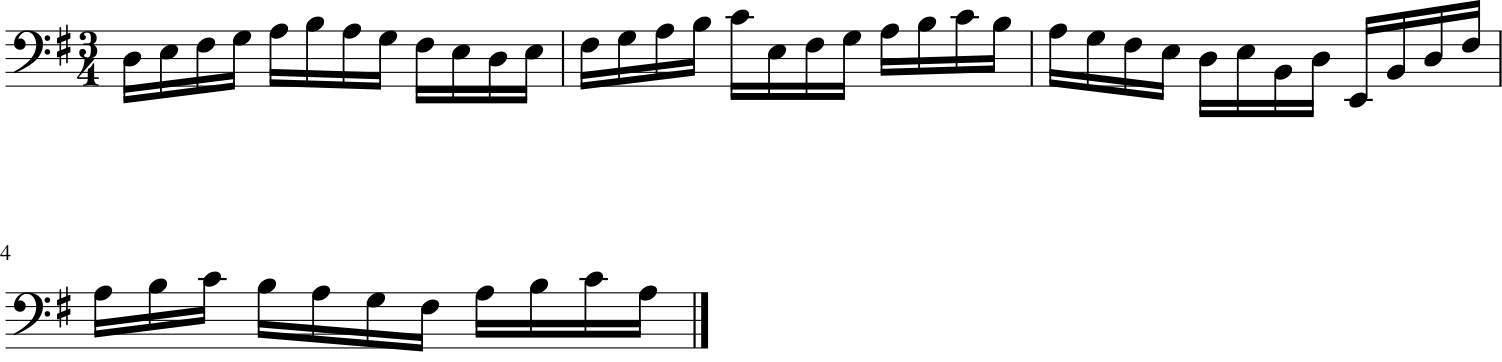

107/107 ━━━━━━━━━━━━━━━━━━━━ 70s 661ms/step - duration_outputs_loss: 0.5512 - loss: 2.5716 - note_outputs_loss: 2.0204
Epoch 18/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.5480 - loss: 2.5127 - note_outputs_loss: 1.9647[['START', np.str_('G:major'), np.str_('4/4TS'), np.str_('rest'), np.str_('C4'), np.str_('B3'), np.str_('A3'), np.str_('B3'), np.str_('B3'), np.str_('B3'), np.str_('A3'), np.str_('G3'), np.str_('F#3'), np.str_('E3'), np.str_('D3'), np.str_('E3'), np.str_('F#3'), np.str_('D3'), np.str_('E3'), np.str_('F#3'), np.str_('D3'), np.str_('A3'), np.str_('F#3'), np.str_('G3'), np.str_('A3'), np.str_('B3'), np.str_('G3'), np.str_('A3'), np.str_('B3'), np.str_('C4'), np.str_('D4'), np.str_('B3'), np.str_('A3'), np.str_('G3'), np.str_('F#3'), np.str_('E3'), np.str_('D3'), np.str_('C3'), np.str_('B2'), np.str_('A2'), np.str_('G2'), np.str_('F#2'), np.str_('A2'), np.str_('B2'), np.str_('C#3'), np.str_('D3'), np.str_('E3'), np.str_('F#3'), np.str_('D3')], ['0.

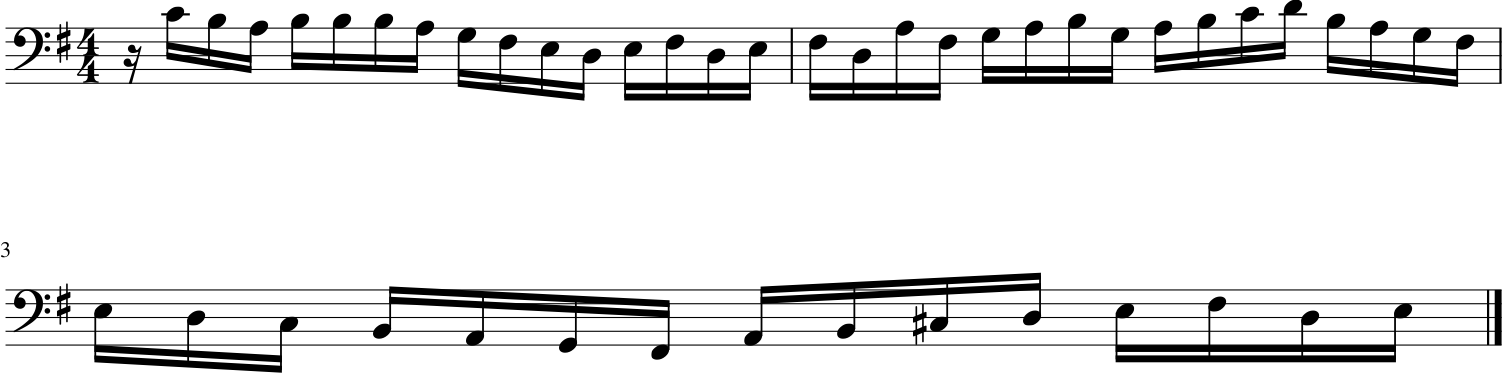

107/107 ━━━━━━━━━━━━━━━━━━━━ 70s 662ms/step - duration_outputs_loss: 0.5627 - loss: 2.5642 - note_outputs_loss: 2.0016
Epoch 19/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.5580 - loss: 2.4860 - note_outputs_loss: 1.9280[['START', np.str_('E-:major'), np.str_('4/4TS'), np.str_('rest'), np.str_('B-2'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('G3'), np.str_('G#3'), np.str_('G3'), np.str_('F3'), np.str_('G3'), np.str_('B-3'), np.str_('G#3'), np.str_('G3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('G3'), np.str_('B-3'), np.str_('G#3'), np.str_('G3'), np.str_('F3'), np.str_('G3'), np.str_('G#3'), np.str_('G3'), np.str_('F3'), np.str_('G3'), np.str_('G#3'), np.str_('B-3'), np.str_('C4'), np.str_('C#4'), np.str_('B-3'), np.str_('C4'), np.str_('B-3'), np.str_('C4'), np.str_('B-3'), np.str_('C4'), np.str_('B-3'), np.str_('C4'), np.str_('B-3'), np.str_('C4'), np.str_('B-3'), np.str_('C4'), np.str_('B-3'), np.str_

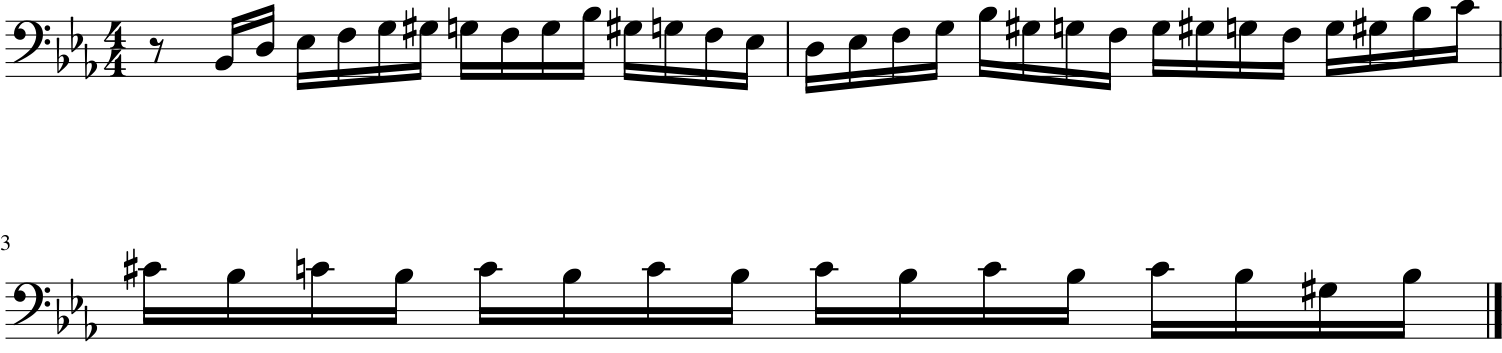

107/107 ━━━━━━━━━━━━━━━━━━━━ 70s 660ms/step - duration_outputs_loss: 0.5499 - loss: 2.5153 - note_outputs_loss: 1.9654
Epoch 20/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - duration_outputs_loss: 0.5684 - loss: 2.5319 - note_outputs_loss: 1.9635[['START', np.str_('E-:major'), np.str_('4/4TS'), np.str_('rest'), np.str_('E-3'), np.str_('F3'), np.str_('G3'), np.str_('G#3'), np.str_('G3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('C3'), np.str_('B-2'), np.str_('D3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('G3'), np.str_('G#3'), np.str_('G3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('C3'), np.str_('D3'), np.str_('E-3'), np.str_('F3'), np.str_('G3'), np.str_('G#3'), np.str_('B-3'), np.str_('G3'), np.str_('G#3'), np.str_('B-3'), np.str_('C4'), np.str_('D4'), np.str_('E-4'), np.str_('D4'), np.str_('C4'), np.str_('B-3'), np.str_('G#3'), np.str_('G3'), np.str_('F3'), np.str_('E-3'), np.str_('D3'), np.str_('E-3'), np.str_('

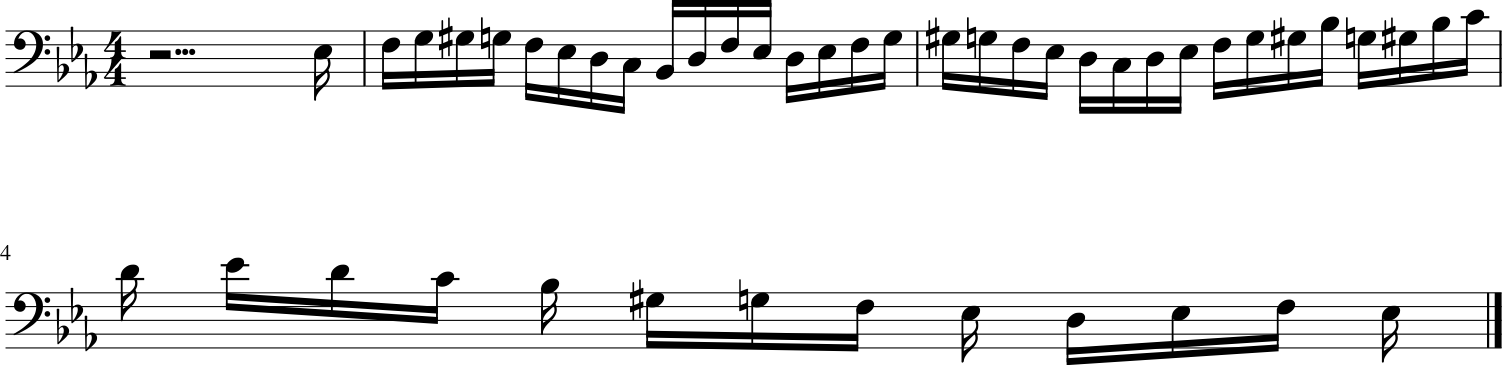

107/107 ━━━━━━━━━━━━━━━━━━━━ 70s 660ms/step - duration_outputs_loss: 0.5430 - loss: 2.4898 - note_outputs_loss: 1.9468


In [ ]:
model.fit(
    ds,
    epochs=EPOCHS,
    callbacks=[
        model_checkpoint_callback,
        tensorboard_callback,
        music_generator,
    ],
)

In [ ]:
# Save the final model
model.save("./models/model.keras")

# 3. Generate music using the Transformer

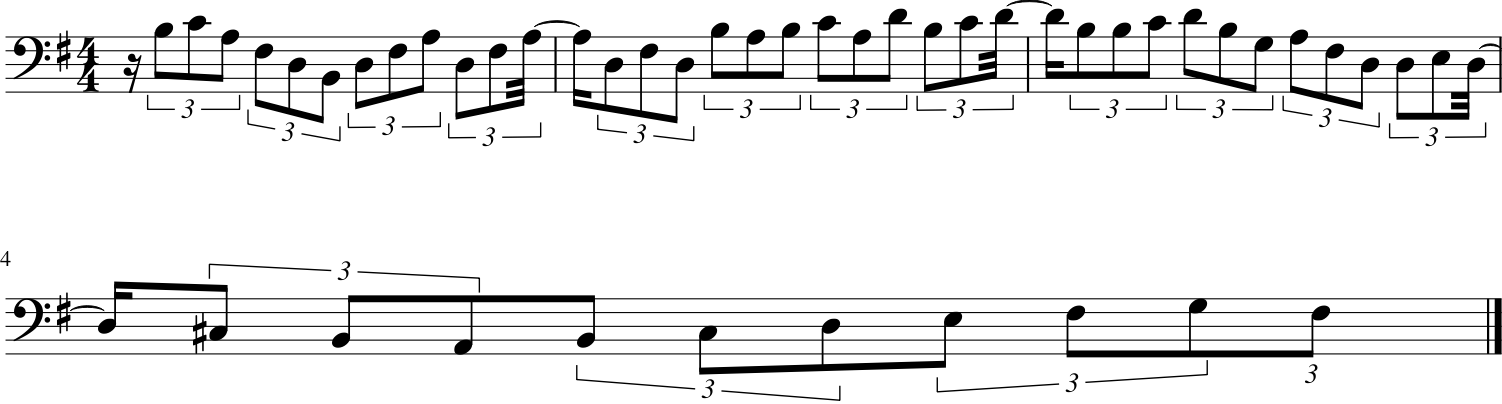

In [ ]:
info = music_generator.generate(
    ["START"], ["0.0"], max_tokens=50, temperature=0.5
)
midi_stream = info[-1]["midi"].chordify()
midi_stream.show()

## Write music to MIDI file

In [ ]:
timestr = time.strftime("%Y%m%d-%H%M%S")
midi_stream.write(
    "midi",
    fp=os.path.join(
        # "/app/notebooks/11_music/01_transformer/output",
        OUTPUT_DIR,
        "output-" + timestr + ".mid",
    ),
)

'output/output-20260809-194912.mid'

## Note probabilities

In [ ]:
max_pitch = 70
seq_len = len(info)
grid = np.zeros((max_pitch, seq_len), dtype=np.float32)

for j in range(seq_len):
    for i, prob in enumerate(info[j]["note_probs"]):
        try:
            pitch = music21.note.Note(notes_vocab[i]).pitch.midi
            grid[pitch, j] = prob
        except:
            pass  # Don't show key / time signatures

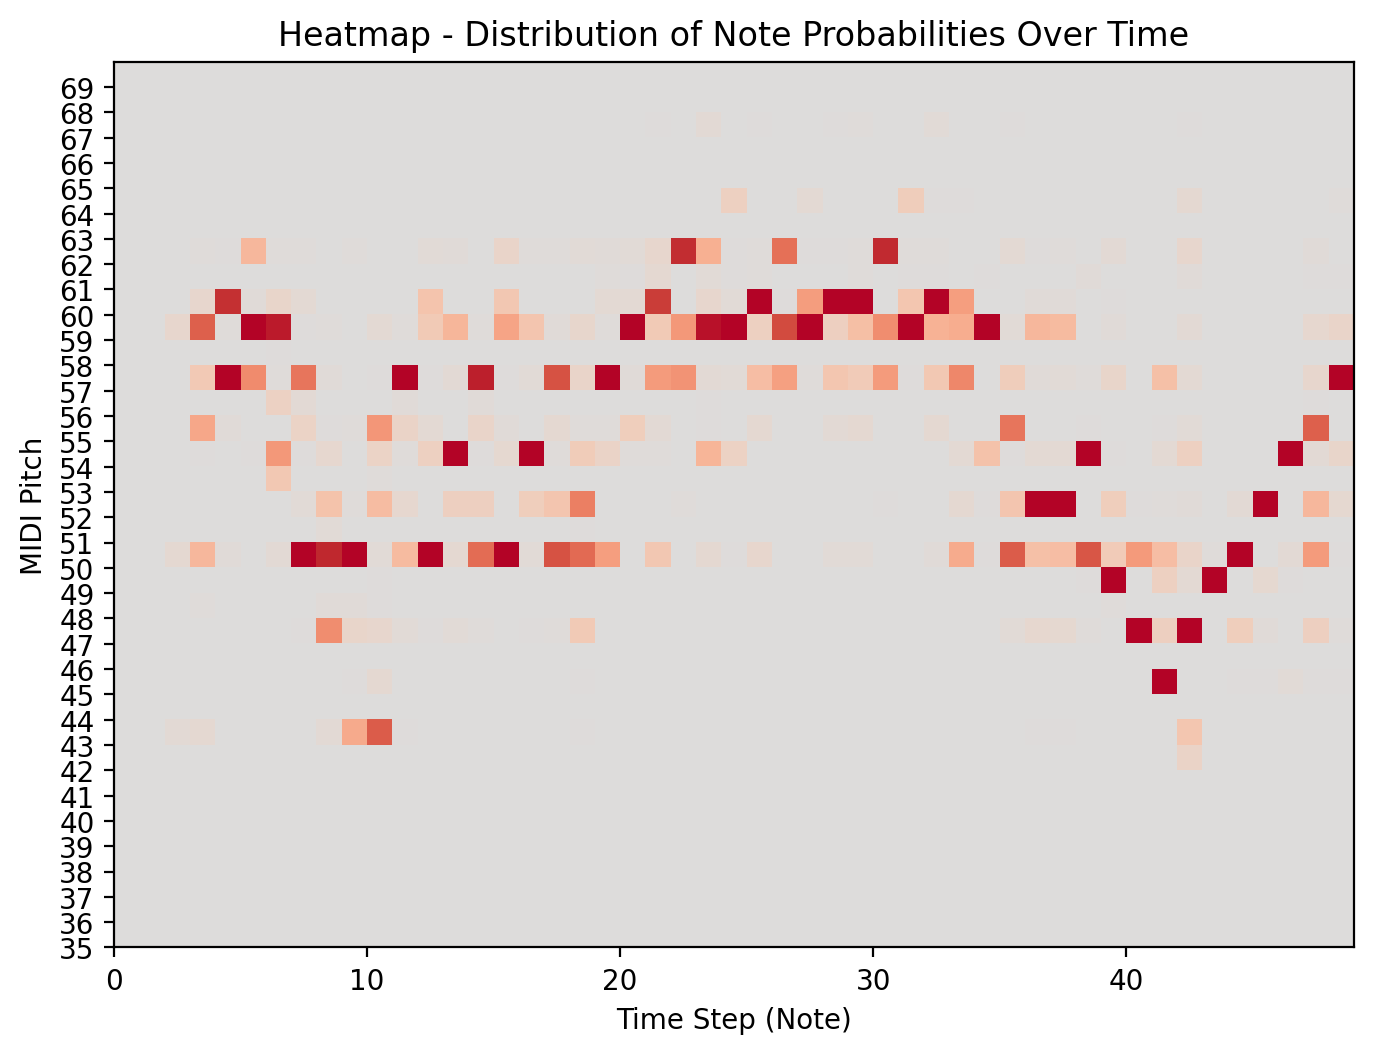

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_yticks([int(j) for j in range(35, 70)])
plt.imshow(
    grid[35:70, :],
    origin="lower",
    cmap="coolwarm",
    vmin=-0.5,
    vmax=0.5,
    extent=[0, seq_len, 35, 70],
)
ax.set_title("Heatmap - Distribution of Note Probabilities Over Time")
ax.set_xlabel("Time Step (Note)")
ax.set_ylabel("MIDI Pitch")
plt.show()

## Attention Plot

In [ ]:
plot_size = 20

att_matrix = np.zeros((plot_size, plot_size))
prediction_output = []
last_prompt = []

In [ ]:
for j in range(plot_size):
    atts = info[j]["atts"].max(axis=0)
    att_matrix[: (j + 1), j] = atts
    prediction_output.append(info[j]["chosen_note"][0])
    last_prompt.append(info[j]["prompt"][0][-1])

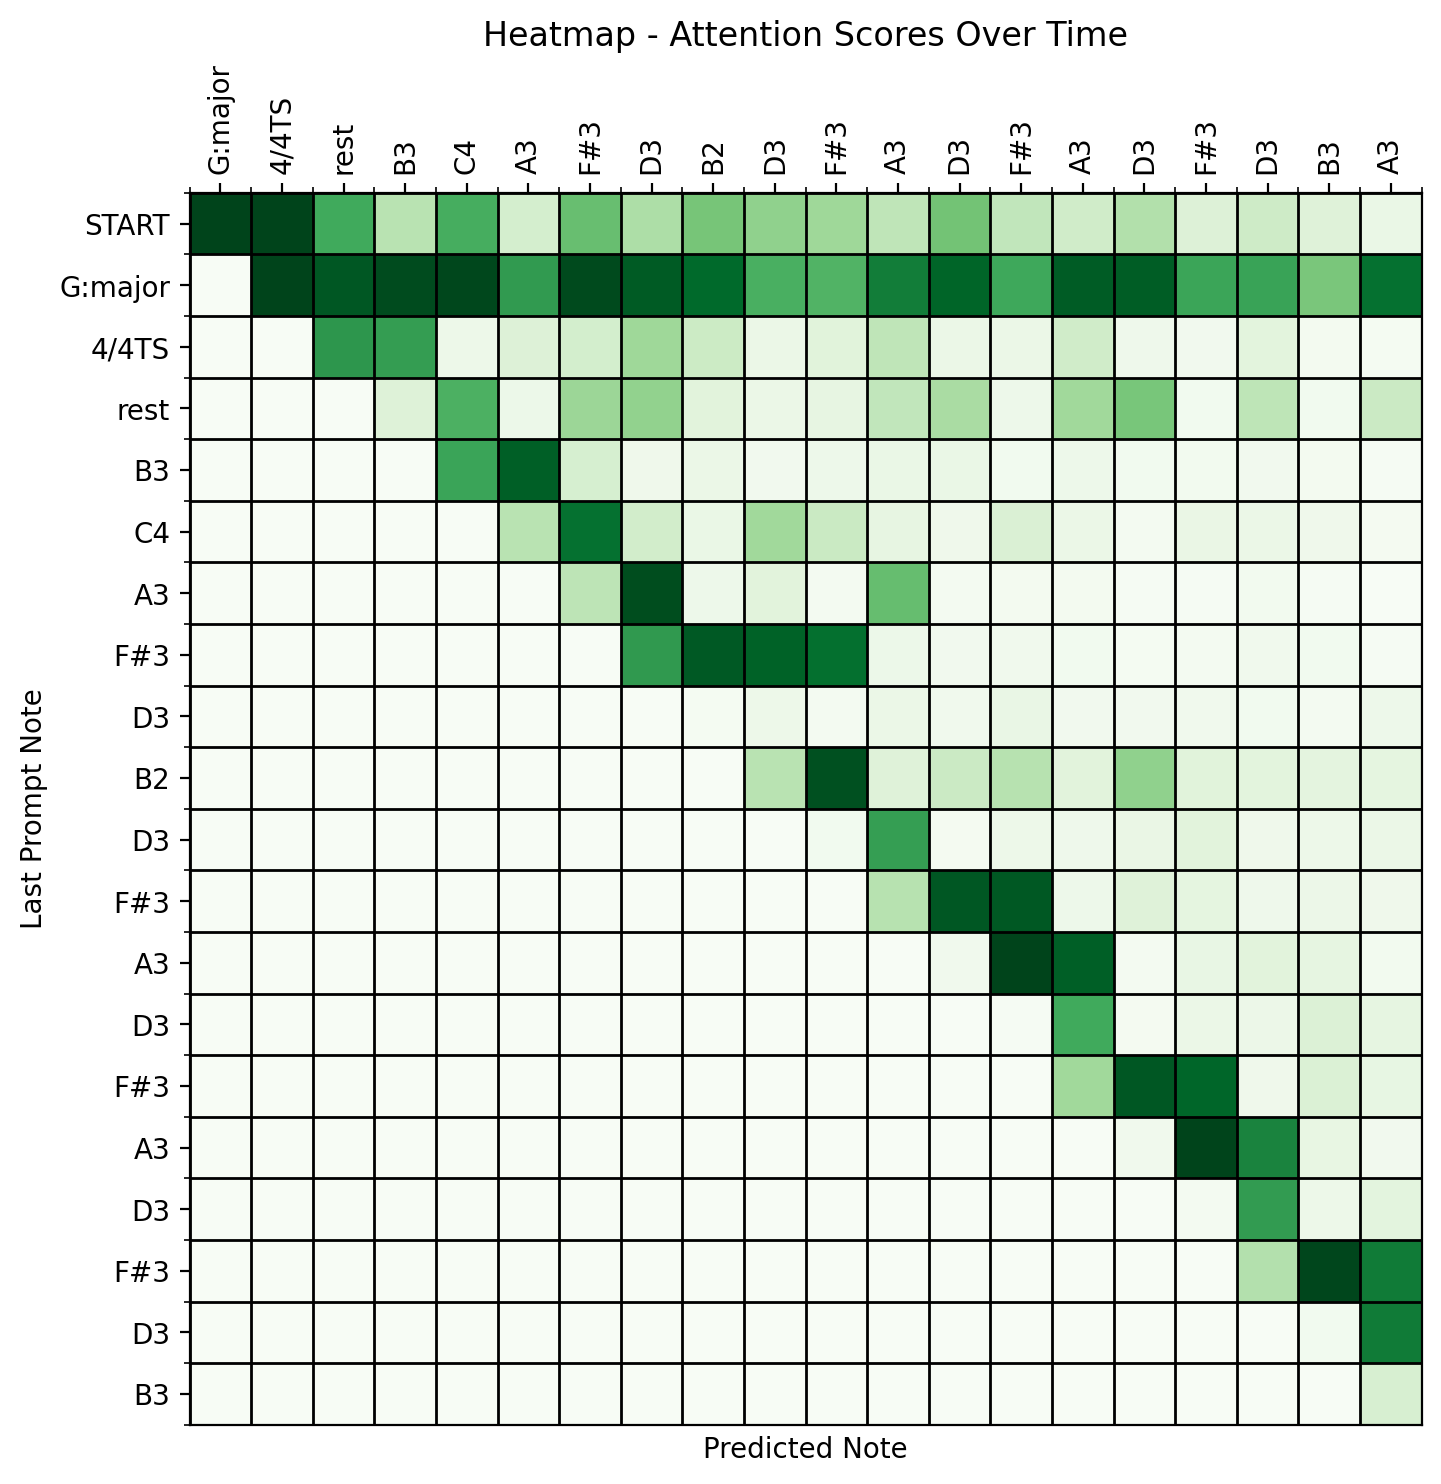

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(att_matrix, cmap="Greens", interpolation="nearest")

ax.set_xticks(np.arange(-0.5, plot_size, 1), minor=True)
ax.set_yticks(np.arange(-0.5, plot_size, 1), minor=True)
ax.grid(which="minor", color="black", linestyle="-", linewidth=1)
ax.set_xticks(np.arange(plot_size))
ax.set_yticks(np.arange(plot_size))
ax.set_xticklabels(prediction_output[:plot_size])
ax.set_yticklabels(last_prompt[:plot_size])
ax.xaxis.tick_top()

ax.set_title("Heatmap - Attention Scores Over Time")
ax.set_xlabel("Predicted Note")
ax.set_ylabel("Last Prompt Note")

plt.setp(
    ax.get_xticklabels(),
    rotation=90,
    ha="left",
    va="center",
    rotation_mode="anchor",
)
plt.show()